In [ ]:
# --------------------------------------------
#  Import Libraries & Ignore Warnings
# --------------------------------------------

import warnings
warnings.filterwarnings("ignore")  # ignore all warnings

# Data handling
import pandas as pd
import numpy as np

# Time-series models
from statsmodels.tsa.arima.model import ARIMA

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Date/time handling
import datetime as dt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries successfully imported")

Libraries successfully imported


In [ ]:
# --------------------------------------------
# Load Weather + Picnic Data & Preview
# --------------------------------------------

# Load weather dataset
weather = pd.read_csv("/content/weather_prediction_dataset_light.csv")

# Load picnic label dataset (optional classification target)
picnic = pd.read_csv("/content/weather_prediction_picnic_labels.csv")

# Convert DATE column to datetime in both datasets
weather['DATE'] = pd.to_datetime(weather['DATE'], format='%Y%m%d')
picnic['DATE'] = pd.to_datetime(picnic['DATE'], format='%Y%m%d')

# Merge datasets based on DATE
df = weather.merge(picnic, on='DATE', how='left')

# Sort by date and set index
df = df.sort_values("DATE").set_index("DATE")

# Preview merged data
print("Merged Dataset Preview:")
display(df.head())

# Shape of merged dataset
print("\nMerged Dataset Shape:", df.shape)

# Check missing values after merge
print("\nMissing Value Summary:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Merged Dataset Preview:


,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,DE_BILT_cloud_cover,DE_BILT_humidity,DE_BILT_pressure,DE_BILT_global_radiation,DE_BILT_precipitation,DE_BILT_sunshine,DE_BILT_temp_mean,DE_BILT_temp_min,DE_BILT_temp_max,DRESDEN_cloud_cover,DRESDEN_humidity,DRESDEN_global_radiation,DRESDEN_precipitation,DRESDEN_sunshine,DRESDEN_temp_mean,DRESDEN_temp_min,DRESDEN_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MALMO_precipitation,MALMO_temp_mean,MALMO_temp_min,MALMO_temp_max,MUENCHEN_cloud_cover,MUENCHEN_humidity,MUENCHEN_pressure,MUENCHEN_global_radiation,MUENCHEN_precipitation,MUENCHEN_sunshine,MUENCHEN_temp_mean,MUENCHEN_temp_min,MUENCHEN_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,BASEL_picnic_weather,BUDAPEST_picnic_weather,DE_picnic_weather,DRESDEN_picnic_weather,DUSSELDORF_picnic_weather,HEATHROW_picnic_weather,KASSEL_picnic_weather,LJUBLJANA_picnic_weather,MAASTRICHT_picnic_weather,MALMO_picnic_weather,MONTELIMAR_picnic_weather,MUENCHEN_picnic_weather,OSLO_picnic_weather,PERPIGNAN_picnic_weather,SONNBLICK_picnic_weather,STOCKHOLM_picnic_weather,TOURS_picnic_weather
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-01-01,1,8,0.890,1.029,0.200,0.030,0.000,2.900,1.600,3.900,7,0.970,1.024,0.110,0.100,0.000,6.100,3.500,8.100,8,0.890,0.090,0.320,0.000,1.000,-1.800,2.000,8,0.920,1.024,0.120,0.220,0.000,4.200,2.500,6.900,7,0.940,1.024,0.180,0.000,0.400,7.000,4.900,10.800,0.930,1.024,0.060,0.130,0.000,3.500,1.500,5.000,8,0.980,1.025,0.060,0.170,0.000,5.600,4.100,6.900,0.270,2.900,0.900,3.600,8,0.910,1.027,0.200,0.200,0.000,1.700,-0.500,2.600,7,0.890,0.820,1.340,0.000,-15.200,-17.000,-13.400,0.970,1.028,0.250,0.040,8.500,7.200,9.800,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2000-01-02,1,8,0.870,1.032,0.250,0.000,0.000,3.600,2.700,4.800,8,0.970,1.027,0.110,0.000,0.000,7.300,5.400,8.700,7,0.890,0.230,0.000,0.400,2.500,1.400,4.000,6,0.870,1.028,0.190,0.000,0.700,6.500,2.700,7.900,7,0.890,1.025,0.200,0.020,0.700,7.900,5.000,11.500,0.920,1.029,0.330,0.000,2.900,2.300,0.300,4.700,7,0.950,1.029,0.140,0.000,0.000,6.200,4.200,7.500,0.000,3.700,1.000,5.400,6,0.900,1.032,0.660,0.000,6.100,1.900,-0.200,5.800,5,0.860,0.600,0.390,2.800,-13.700,-15.000,-12.300,0.990,1.029,0.170,0.160,7.900,6.600,9.200,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2000-01-03,1,5,0.810,1.031,0.500,0.000,3.700,2.200,0.100,4.800,8,0.940,1.020,0.110,0.450,0.000,8.400,6.400,9.600,7,0.790,0.180,0.000,0.000,4.200,1.300,5.100,7,0.780,1.024,0.120,0.280,0.000,7.700,6.900,9.100,8,0.910,1.019,0.130,0.600,0.000,9.400,7.200,9.500,0.900,1.025,0.200,0.010,0.000,3.500,2.200,4.600,7,0.870,1.024,0.150,0.020,0.900,6.800,6.100,7.900,0.060,5.600,4.000,6.900,7,0.920,1.032,0.280,0.000,0.400,-0.400,-3.300,0.900,3,0.410,0.810,0.000,5.100,-9.200,-12.500,-5.800,0.910,1.027,0.270,0.000,8.100,6.


Merged Dataset Shape: (3654, 107)

Missing Value Summary:


,0
MONTH,0
BASEL_cloud_cover,0
BASEL_humidity,0
BASEL_pressure,0
BASEL_global_radiation,0
BASEL_precipitation,0
BASEL_sunshine,0
BASEL_temp_mean,0
BASEL_temp_min,0
BASEL_temp_max,0


In [ ]:
# --------------------------------------------
# Exploratory Data Analysis (EDA)
# --------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Ensuring visuals are clear
sns.set(rc={"figure.figsize": (14, 6)})

# -------- Dataset Overview --------
print("Dataset Info:")
display(df.info())

print("\nStatistical Summary:")
display(df.describe().T)

# Check missing values sorted
print("\nTop Missing Values Columns:")
display(df.isnull().sum().sort_values(ascending=False).head(25))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2000-01-01 to 2010-01-01
Columns: 107 entries, MONTH to TOURS_picnic_weather
dtypes: bool(17), float64(81), int64(9)
memory usage: 2.6 MB


None


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
MONTH,3654.000,6.521,3.450,1.000,4.000,7.000,10.000,12.000
BASEL_cloud_cover,3654.000,5.418,2.325,0.000,4.000,6.000,7.000,8.000
BASEL_humidity,3654.000,0.745,0.108,0.380,0.670,0.760,0.830,0.980
BASEL_pressure,3654.000,1.018,0.008,0.986,1.013,1.018,1.023,1.041
BASEL_global_radiation,3654.000,1.330,0.935,0.050,0.530,1.110,2.060,3.550
...,...,...,...,...,...,...,...,...
TOURS_global_radiation,3654.000,1.370,0.926,0.050,0.550,1.235,2.090,3.560
TOURS_precipitation,3654.000,0.186,0.422,0.000,0.000,0.000,0.160,6.200
TOURS_temp_mean,3654.000,12.206,6.467,-6.200,7.600,12.300,17.200,31.200
TOURS_temp_min,3654.000,7.861,5.692,-13.000,3.700,8.300,12.300,22.600



Top Missing Values Columns:


,0
MONTH,0
BASEL_cloud_cover,0
BASEL_humidity,0
BASEL_pressure,0
BASEL_global_radiation,0
BASEL_precipitation,0
BASEL_sunshine,0
BASEL_temp_mean,0
BASEL_temp_min,0
BASEL_temp_max,0


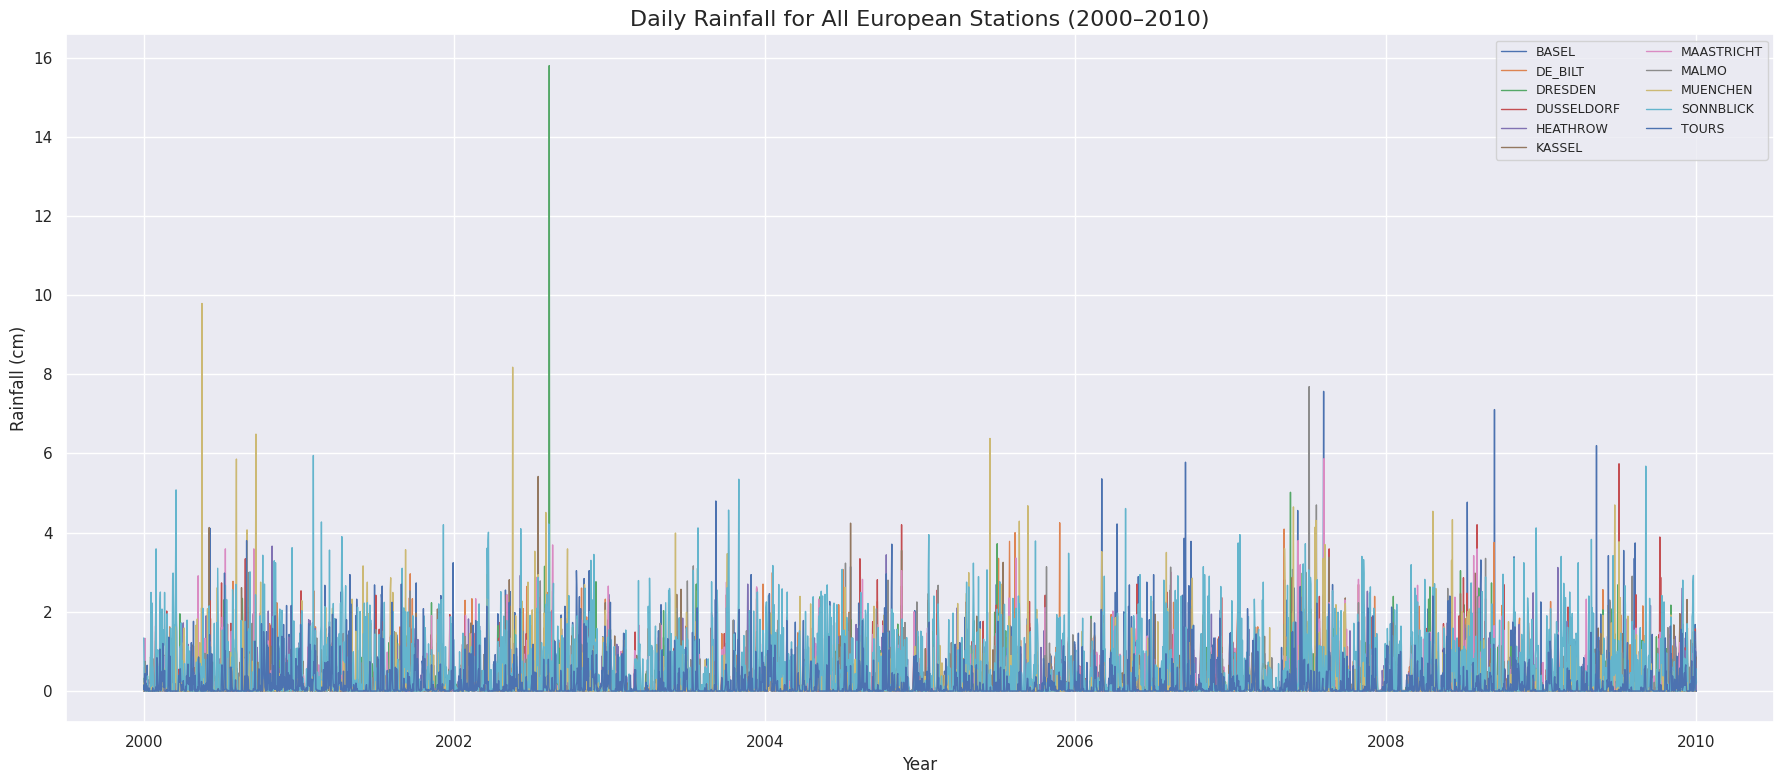

In [ ]:
# --------------------------------------------------
# Combined Rainfall Plot for All Stations
# --------------------------------------------------

plt.figure(figsize=(18, 8))

# Find all precipitation columns
precip_cols = [c for c in df.columns if c.endswith("_precipitation")]

for col in precip_cols:
    station_name = col.replace("_precipitation", "")
    plt.plot(df.index, df[col], linewidth=1, label=station_name)

plt.title("Daily Rainfall for All European Stations (2000–2010)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Rainfall (cm)")
plt.legend(loc="upper right", ncol=2, fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

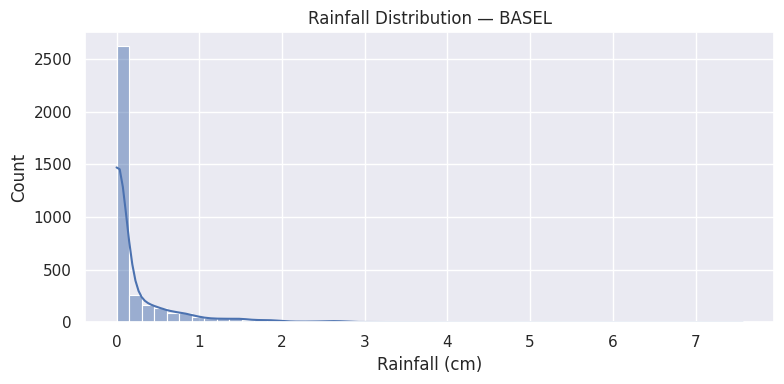

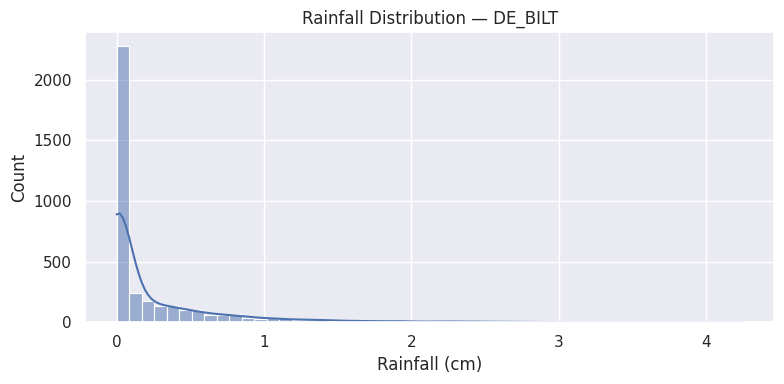

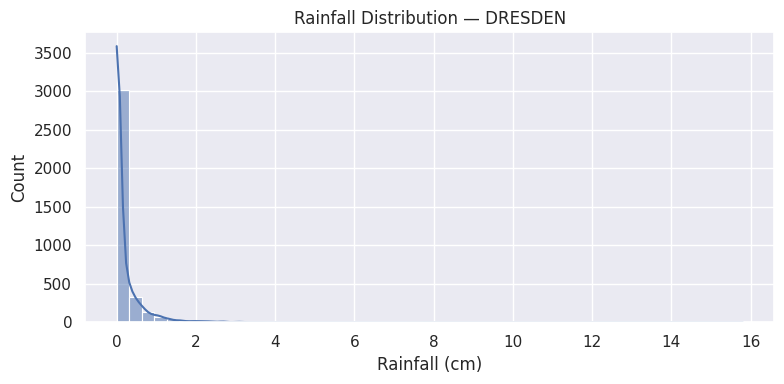

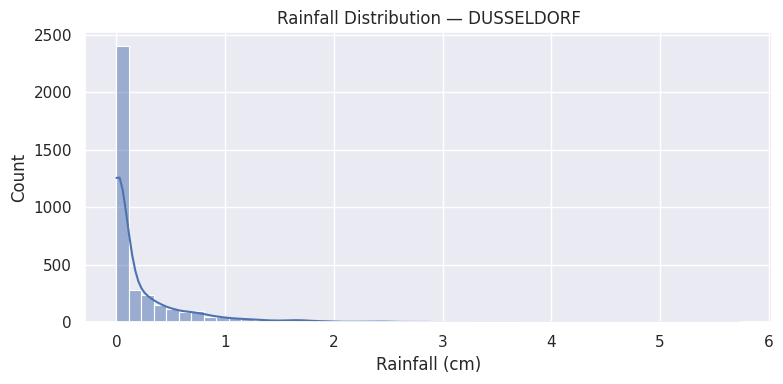

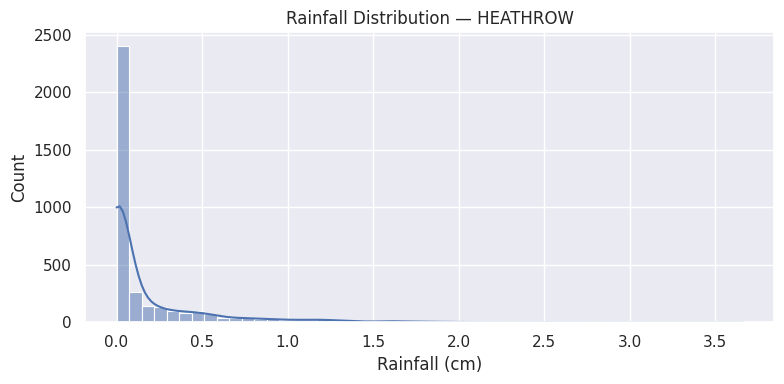

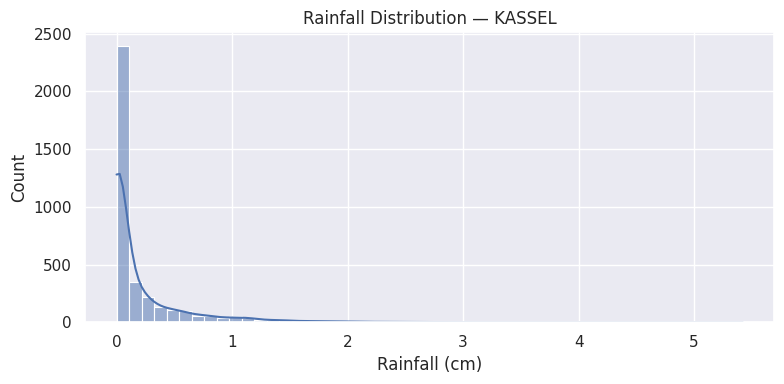

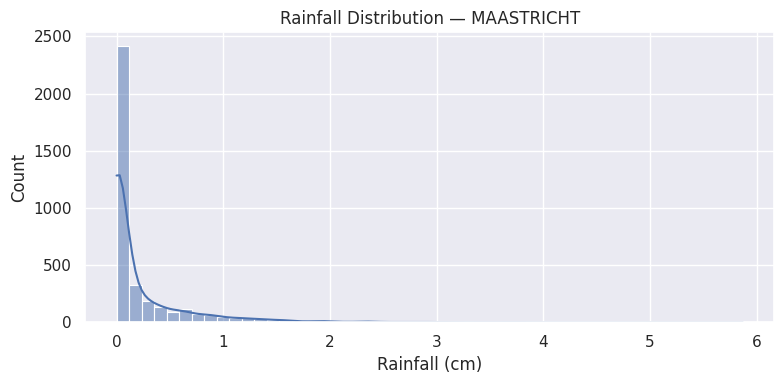

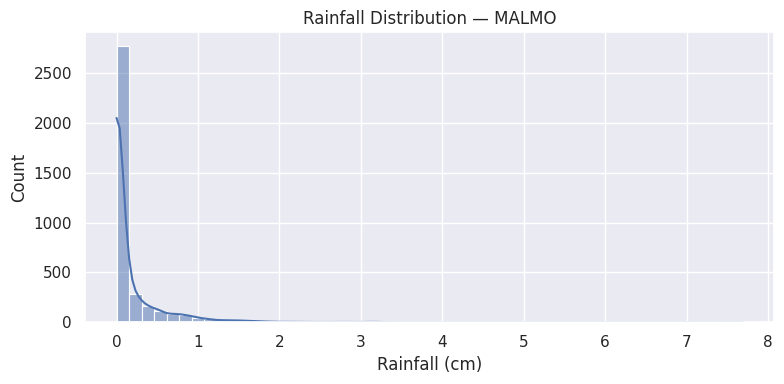

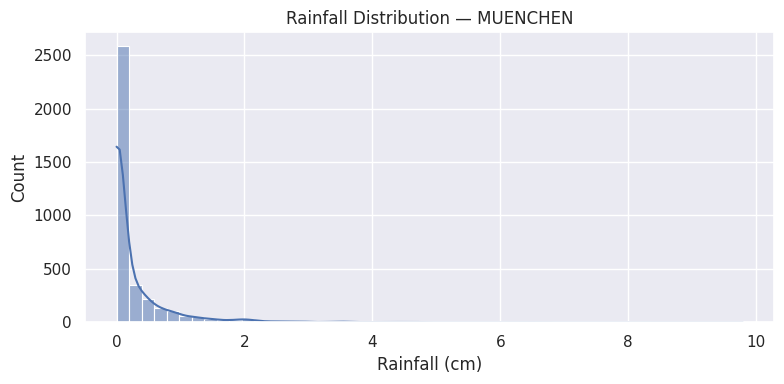

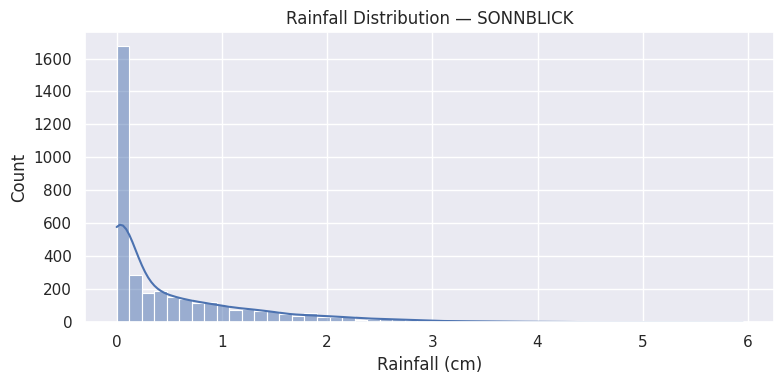

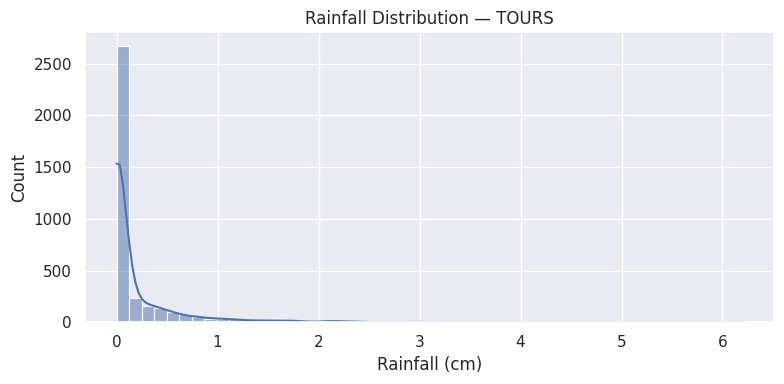

In [ ]:
# --------------------------------------------------
# Rainfall Distribution (Histogram per station)
# --------------------------------------------------

for col in precip_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Rainfall Distribution — {col.replace('_precipitation', '')}")
    plt.xlabel("Rainfall (cm)")
    plt.tight_layout()
    plt.show()

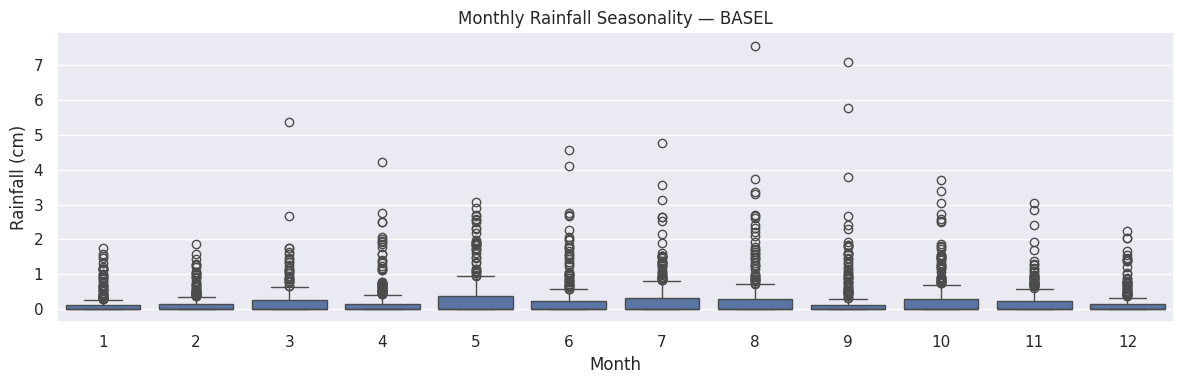

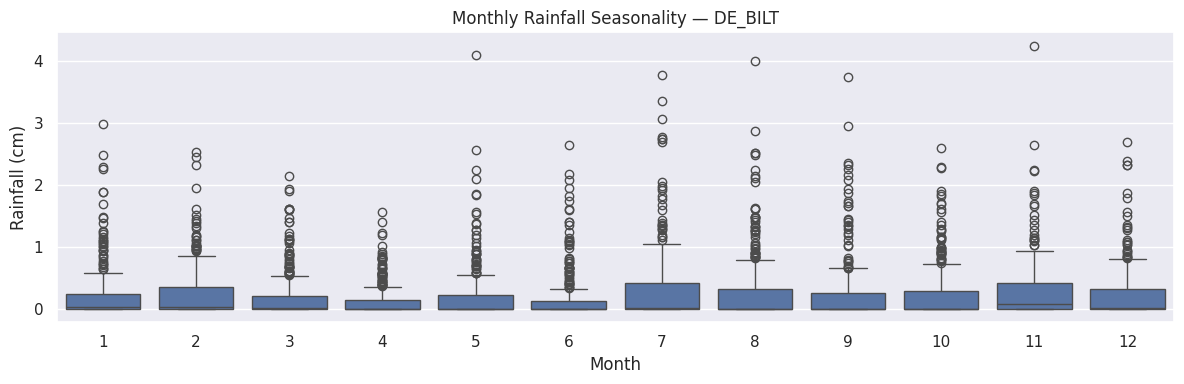

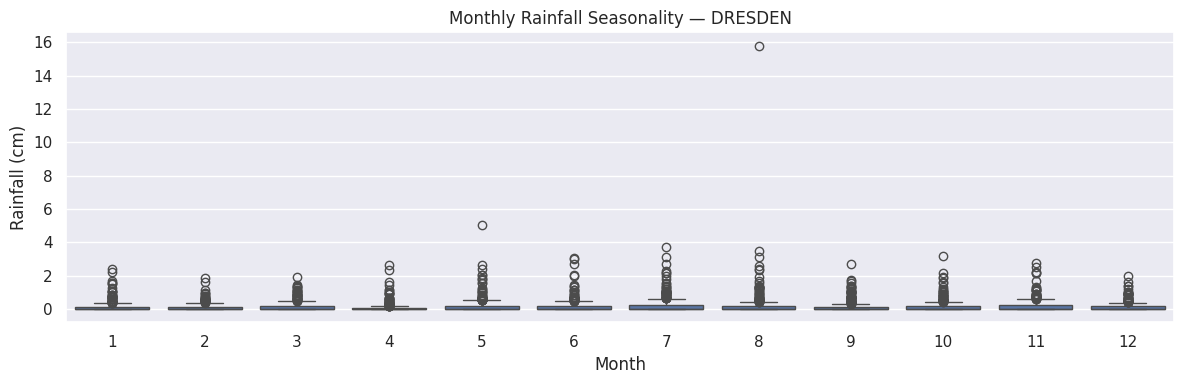

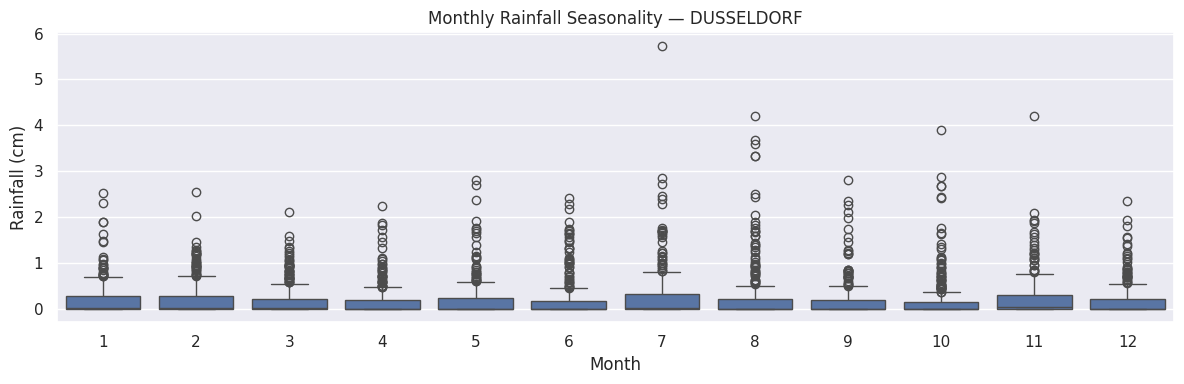

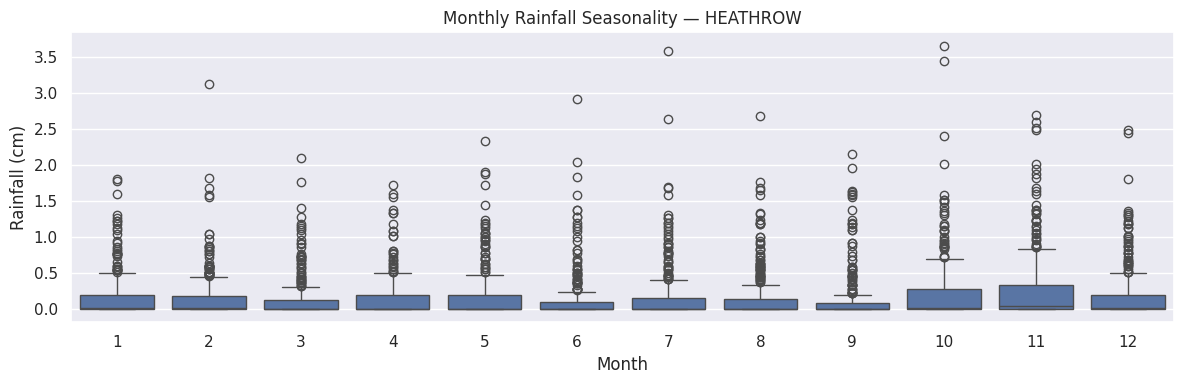

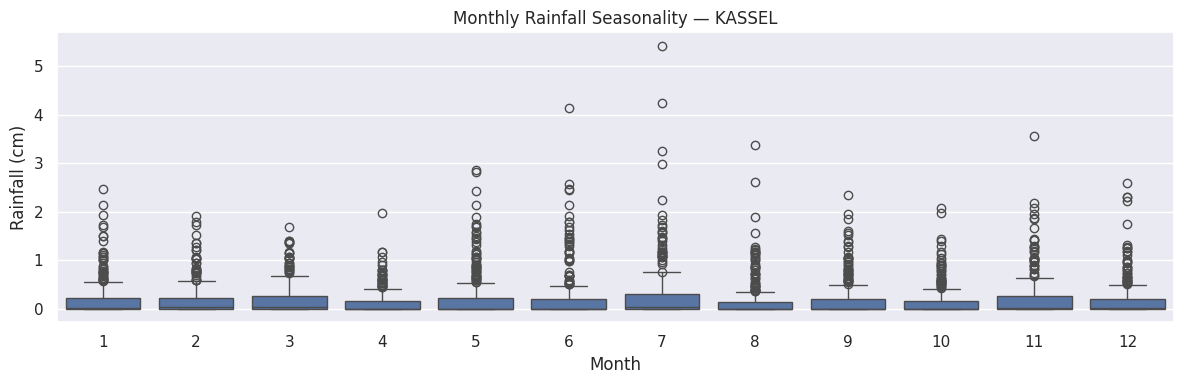

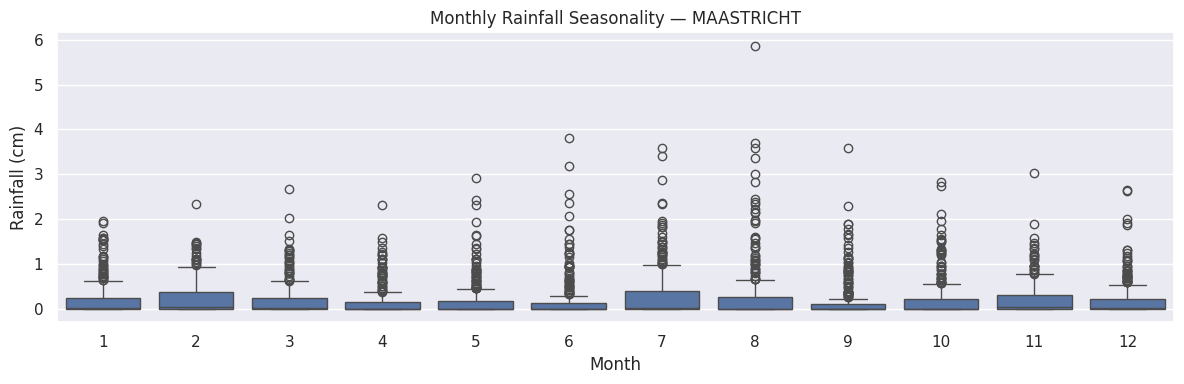

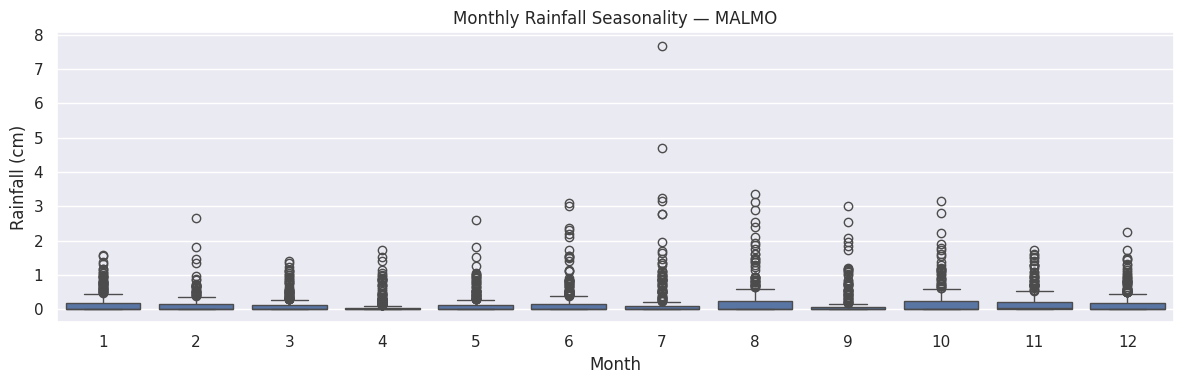

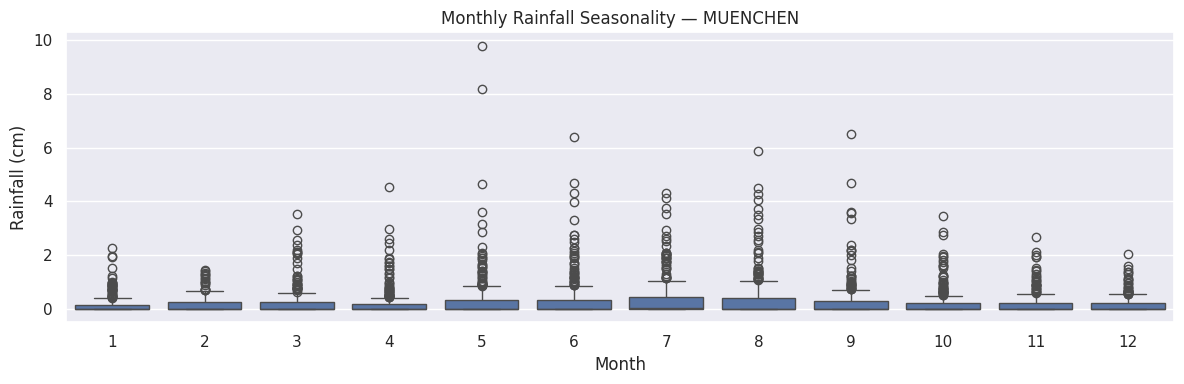

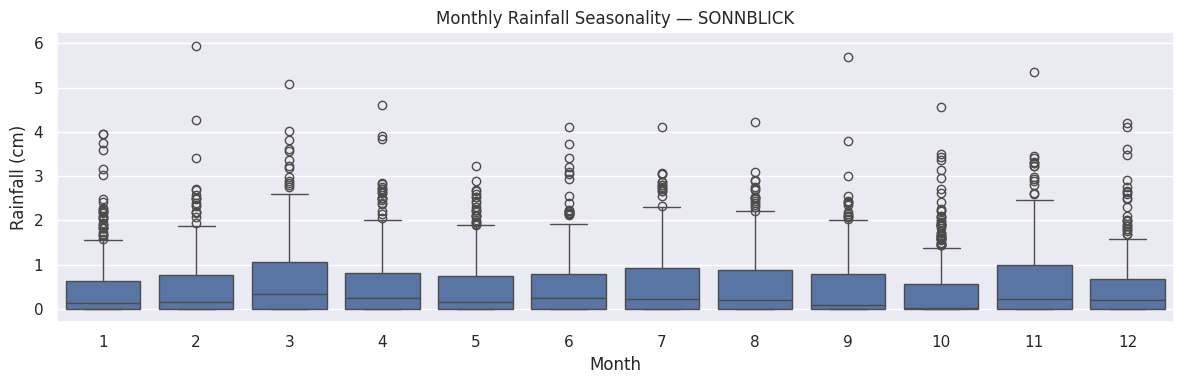

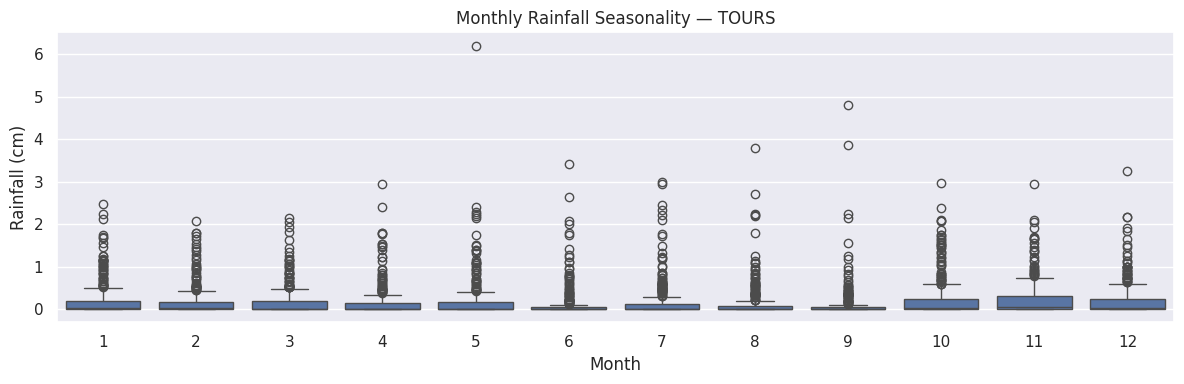

In [ ]:
# --------------------------------------------------
# Monthly Seasonality Boxplots per station
# --------------------------------------------------

df["MONTH"] = df.index.month

for col in precip_cols:
    plt.figure(figsize=(12, 4))
    sns.boxplot(x="MONTH", y=col, data=df)
    plt.title(f"Monthly Rainfall Seasonality — {col.replace('_precipitation', '')}")
    plt.xlabel("Month")
    plt.ylabel("Rainfall (cm)")
    plt.tight_layout()
    plt.show()

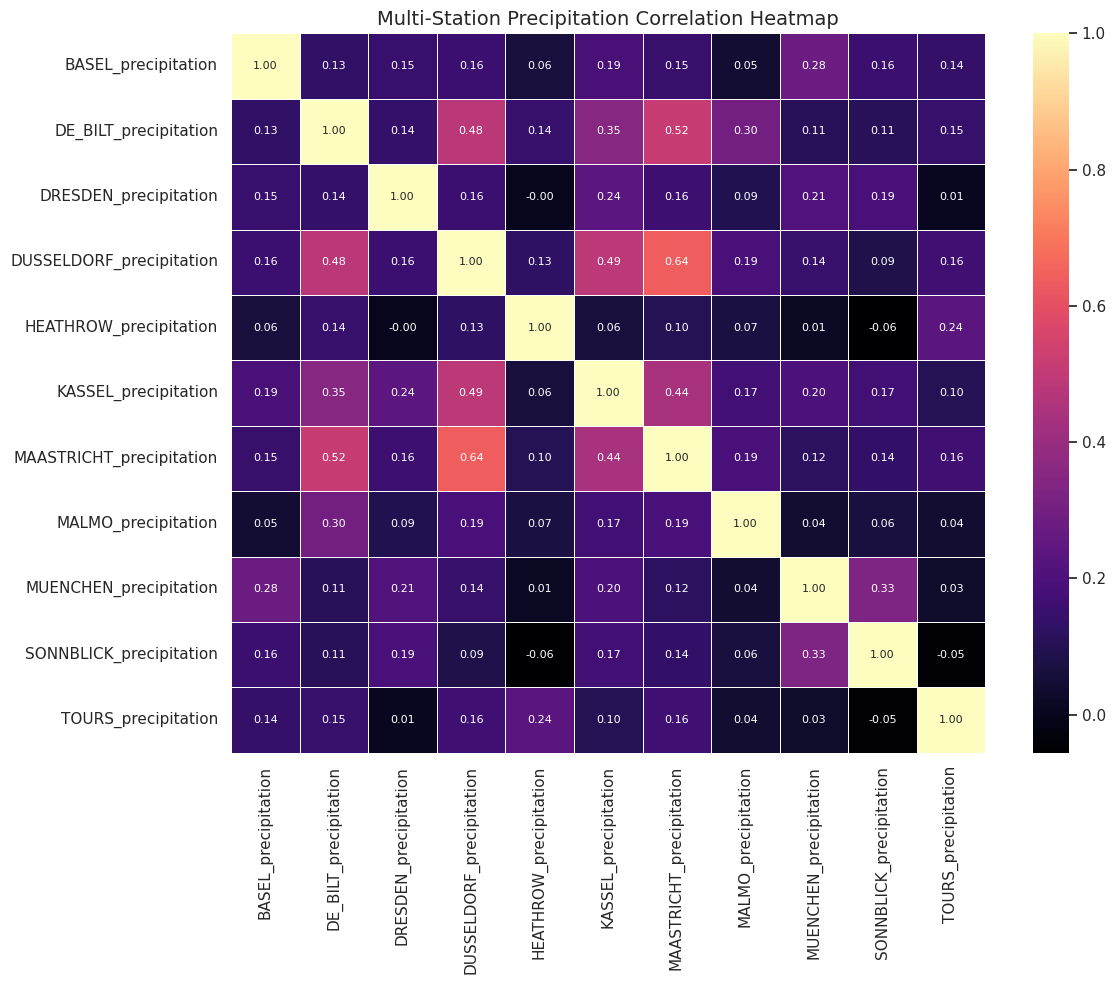

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df[precip_cols].corr(),
    annot=True,             # show correlation values
    fmt=".2f",               # 2 decimal places
    cmap="magma",
    linewidths=0.5,          # grid lines
    annot_kws={"size": 8}    # text size
)
plt.title("Multi-Station Precipitation Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Identify weather stations by prefix (ending in precipitation)
weather_stations = sorted([c.replace("_precipitation", "")
                           for c in df.columns if c.endswith("_precipitation")])

print("Weather Stations:", weather_stations)
print("Count:", len(weather_stations))

Weather Stations: ['BASEL', 'DE_BILT', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'MAASTRICHT', 'MALMO', 'MUENCHEN', 'SONNBLICK', 'TOURS']
Count: 11


In [ ]:
# Identify picnic stations
picnic_stations = sorted([c.replace("_picnic_weather", "")
                          for c in df.columns if c.endswith("_picnic_weather")])

print("\nPicnic Stations:", picnic_stations)
print("Count:", len(picnic_stations))


Picnic Stations: ['BASEL', 'BUDAPEST', 'DE', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MALMO', 'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN', 'SONNBLICK', 'STOCKHOLM', 'TOURS']
Count: 17


In [ ]:
valid_stations = sorted(list(set(weather_stations) & set(picnic_stations)))

print("\nValid Stations To Use:", valid_stations)
print("Valid Count:", len(valid_stations))


Valid Stations To Use: ['BASEL', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'MAASTRICHT', 'MALMO', 'MUENCHEN', 'SONNBLICK', 'TOURS']
Valid Count: 10


In [ ]:
# -----------------------------------------------------------
# 🌦️ Final Robust Picnic Classification for ALL Stations
# -----------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

results = []

picnic_cols = [c for c in df.columns if c.endswith("_picnic_weather")]
stations = valid_stations

print(f"Stations detected: {len(stations)}")

for station in stations:
    print(f"\n Processing station: {station}")

    station_cols = [c for c in df.columns if c.startswith(station + "_")]
    data_station = df[station_cols].copy()

    target = f"{station}_picnic_weather"
    if target not in data_station.columns:
        print(f" Missing picnic label for {station}, skipping …")
        continue

    # Encode boolean → numeric
    data_station[target] = data_station[target].astype(int)

    # Remove NaN
    data_station.dropna(inplace=True)

    # Must have at least 100 observations to train reliably
    if len(data_station) < 100:
        print(f" Not enough samples for {station} ({len(data_station)}), skipping …")
        continue

    # Split features/target
    X = data_station.drop(columns=[target])
    y = data_station[target]

    # Must have at least 1 feature
    if X.shape[1] < 1:
        print(f" No usable features for {station}, skipping …")
        continue

    # Must have at least 2 unique classes (0 & 1)
    if y.nunique() < 2:
        print(f" Station {station} contains only one class ({y.unique()[0]}), skipping …")
        continue

    # Time-based split (80% train / 20% test)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Final safety: not empty
    if len(X_train) == 0 or len(X_test) == 0:
        print(f" Train/Test split issue, skipping {station} …")
        continue

    # Build & train pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f" Accuracy for {station}: {acc:.3f}")

    results.append({
        "Station": station,
        "Accuracy": acc,
        "Samples Used": len(data_station),
        "Features Used": X.shape[1]
    })


# -----------------------------------------------------------
# Summary Results Table
# -----------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\n================ PICNIC CLASSIFICATION RESULTS ================")
display(results_df.reset_index(drop=True))


Stations detected: 10

 Processing station: BASEL
 Accuracy for BASEL: 0.943

 Processing station: DRESDEN
 Accuracy for DRESDEN: 0.949

 Processing station: DUSSELDORF
 Accuracy for DUSSELDORF: 0.934

 Processing station: HEATHROW
 Accuracy for HEATHROW: 0.953

 Processing station: KASSEL
 Accuracy for KASSEL: 0.941

 Processing station: MAASTRICHT
 Accuracy for MAASTRICHT: 0.945

 Processing station: MALMO
 Accuracy for MALMO: 0.948

 Processing station: MUENCHEN
 Accuracy for MUENCHEN: 0.938

 Processing station: SONNBLICK
 Station SONNBLICK contains only one class (0), skipping …

 Processing station: TOURS
 Accuracy for TOURS: 0.936

================ PICNIC CLASSIFICATION RESULTS ================


,Station,Accuracy,Samples Used,Features Used
0,HEATHROW,0.953,3654,9
1,DRESDEN,0.949,3654,8
2,MALMO,0.948,3654,4
3,MAASTRICHT,0.945,3654,9
4,BASEL,0.943,3654,9
5,KASSEL,0.941,3654,8
6,MUENCHEN,0.938,3654,9
7,TOURS,0.936,3654,7
8,DUSSELDORF,0.934,3654,9


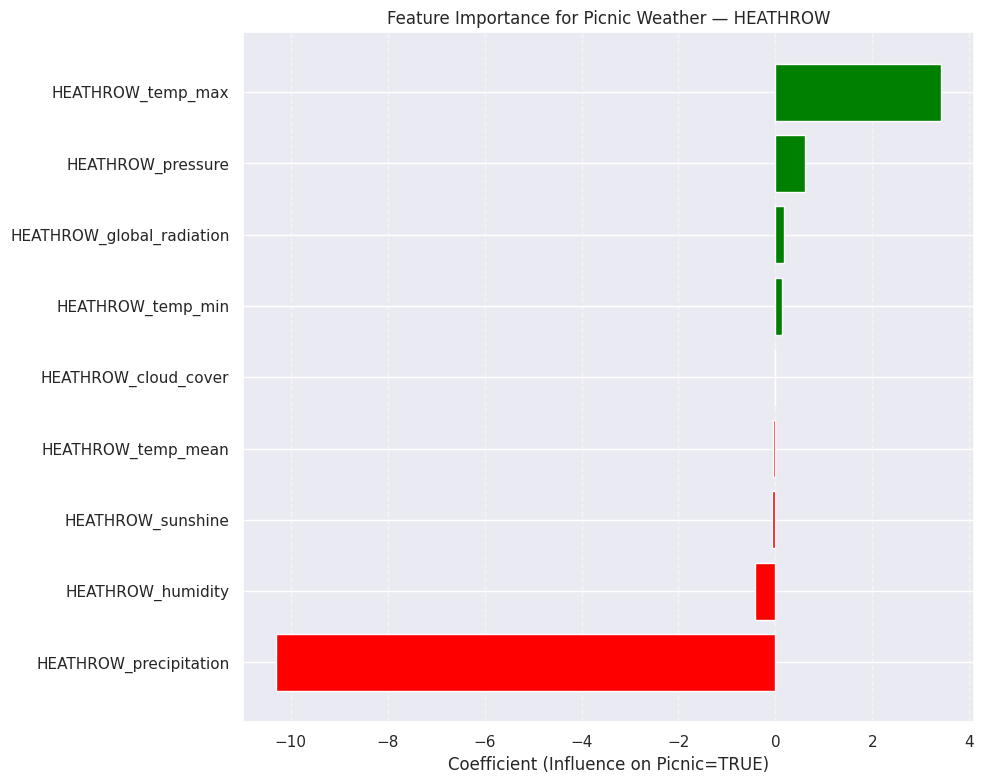

In [ ]:
# ========================================================
# Feature Importance Plot — HEATHROW Picnic Prediction
# ========================================================

station = "HEATHROW"
target = f"{station}_picnic_weather"
station_cols = [c for c in df.columns if c.startswith(station + "_")]
data = df[station_cols].dropna().copy()
data[target] = data[target].astype(int)

# Split features and target
X = data.drop(columns=[target])
y = data[target]

# Train/test split (time-based)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train model again for extraction
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_h = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_h.fit(X_train, y_train)

# Extract coefficients
model = pipeline_h.named_steps["model"]
coeffs = model.coef_[0]
features = X.columns

# Sort by importance
sorted_idx = np.argsort(coeffs)
sorted_features = features[sorted_idx]
sorted_coeffs = coeffs[sorted_idx]

# Plot
plt.figure(figsize=(10, 8))
bars = plt.barh(sorted_features, sorted_coeffs, color=["red" if c < 0 else "green" for c in sorted_coeffs])
plt.title("Feature Importance for Picnic Weather — HEATHROW")
plt.xlabel("Coefficient (Influence on Picnic=TRUE)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
#  Full Rainfall Forecasting Pipeline (ARIMA + XGB + LSTM + Forecast)
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


def run_forecast_pipeline(station_name="BASEL", future_days=30):

    print(f"\n  Running Forecasting Pipeline for: {station_name}")

    # ================== Select Station Data ==================
    target = f"{station_name}_precipitation"
    station_cols = [c for c in df.columns if c.startswith(station_name + "_")]
    data = df[station_cols].dropna().copy()

    if target not in data.columns:
        print(f" Skipping {station_name}: No precipitation data found!")
        return None

    # Lag features for ML/LSTM
    for lag in [1, 3, 7, 14]:
        data[f"{target}_lag{lag}"] = data[target].shift(lag)
    data.dropna(inplace=True)

    # ================== Train/Test Split ==================
    total_len = len(data)
    train_end = int(total_len * 0.8)

    train = data.iloc[:train_end]
    test = data.iloc[train_end:]

    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    print(f" Train samples: {len(train)}, Test samples: {len(test)}")

    # Scale for ML/LSTM
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)


    # ======================================================
    #  ARIMA Model
    # ======================================================
    print("\n Training ARIMA...")
    arima_fit = ARIMA(y_train, order=(2, 1, 2)).fit()

    pred_arima_test = arima_fit.forecast(steps=len(y_test))
    arima_future = arima_fit.forecast(steps=future_days)

    rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima_test))
    mae_arima = mean_absolute_error(y_test, pred_arima_test)


    # ======================================================
    #  XGBoost Model
    # ======================================================
    print(" Training XGBoost...")
    xgb = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6)
    xgb.fit(X_train_s, y_train)

    pred_xgb_test = xgb.predict(X_test_s)

    rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb_test))
    mae_xgb = mean_absolute_error(y_test, pred_xgb_test)

    # Recursive XGB future prediction
    future_X = X_test_s[-1:].copy()
    future_preds_xgb = []

    for _ in range(future_days):
        nxt = xgb.predict(future_X)[0]
        future_preds_xgb.append(nxt)
        future_X = np.roll(future_X, 1)
        future_X[0, 0] = nxt


    # ======================================================
    #  LSTM Model
    # ======================================================
    print(" Training LSTM... (this may take some seconds)")
    seq_len = 14

    def seq_build(Xs, ys):
        X_list, y_list = [], []
        for i in range(len(Xs) - seq_len):
            X_list.append(Xs[i:i+seq_len])
            y_list.append(ys.iloc[i + seq_len])
        return np.array(X_list), np.array(y_list)

    X_scaled_all = scaler.fit_transform(data.drop(columns=[target]))
    X_seq, y_seq = seq_build(X_scaled_all, data[target])

    split = int(len(X_seq) * 0.8)
    X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
    y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

    lstm_model = Sequential([
        LSTM(64, input_shape=(seq_len, X_seq.shape[2])),
        Dense(1)
    ])
    lstm_model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(patience=10, restore_best_weights=True)
    lstm_model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        verbose=0,
        callbacks=[es]
    )

    pred_lstm_test = lstm_model.predict(X_test_seq).flatten()

    rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, pred_lstm_test))
    mae_lstm = mean_absolute_error(y_test_seq, pred_lstm_test)

    # LSTM rolling forecast
    future_seq = X_scaled_all[-seq_len:].copy()
    future_preds_lstm = []
    for _ in range(future_days):
        nxt = lstm_model.predict(future_seq.reshape(1, seq_len, -1), verbose=0)[0][0]
        future_preds_lstm.append(nxt)
        future_seq = np.vstack([future_seq[1:], nxt * np.ones_like(future_seq[0])])


    # ======================================================
    # Summary Performance
    # ======================================================
    print("\n  Model Performance:")
    print(f"ARIMA   → RMSE={rmse_arima:.3f}, MAE={mae_arima:.3f}")
    print(f"XGBoost → RMSE={rmse_xgb:.3f}, MAE={mae_xgb:.3f}")
    print(f"LSTM    → RMSE={rmse_lstm:.3f}, MAE={mae_lstm:.3f}")


    # ======================================================
    # Plot 1 — Actual vs Predicted (Test Only)
    # ======================================================
    plt.figure(figsize=(16,6))
    plt.plot(y_test.index, y_test, label="Actual", color="black", linewidth=2)
    plt.plot(y_test.index, pred_arima_test, "--", label="ARIMA Predicted")
    plt.plot(y_test.index, pred_xgb_test, "-.", label="XGB Predicted")
    plt.plot(y_test.index[-len(pred_lstm_test):], pred_lstm_test, ":", label="LSTM Predicted")

    plt.title(f"{station_name} - Actual vs Predicted Rainfall (Test Data)")
    plt.ylabel("Rainfall (cm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ======================================================
    # Plot 2 — Future Forecast Graph
    # ======================================================
    future_index = pd.date_range(
        start=y_test.index[-1] + pd.Timedelta(days=1),
        periods=future_days,
        freq="D"
    )

    plt.figure(figsize=(16,6))
    plt.plot(y_test.index, y_test, label="Actual (Test)", color="black", linewidth=2)
    plt.plot(future_index, arima_future, "--", label="ARIMA Forecast")
    plt.plot(future_index, future_preds_xgb, "-.", label="XGB Forecast")
    plt.plot(future_index, future_preds_lstm, ":", label="LSTM Forecast")

    plt.title(f"{station_name} - Next {future_days} Days Rainfall Forecast")
    plt.ylabel("Rainfall (cm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ======================================================
    # Return ONLY Metrics for Station Comparison
    # ======================================================
    return {
        "Station": station_name,
        "ARIMA_RMSE": rmse_arima,
        "ARIMA_MAE": mae_arima,
        "XGB_RMSE": rmse_xgb,
        "XGB_MAE": mae_xgb,
        "LSTM_RMSE": rmse_lstm,
        "LSTM_MAE": mae_lstm
    }


  Running Forecasting Pipeline for: BASEL
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

  Model Performance:
ARIMA   → RMSE=0.568, MAE=0.262
XGBoost → RMSE=0.485, MAE=0.232
LSTM    → RMSE=0.557, MAE=0.294


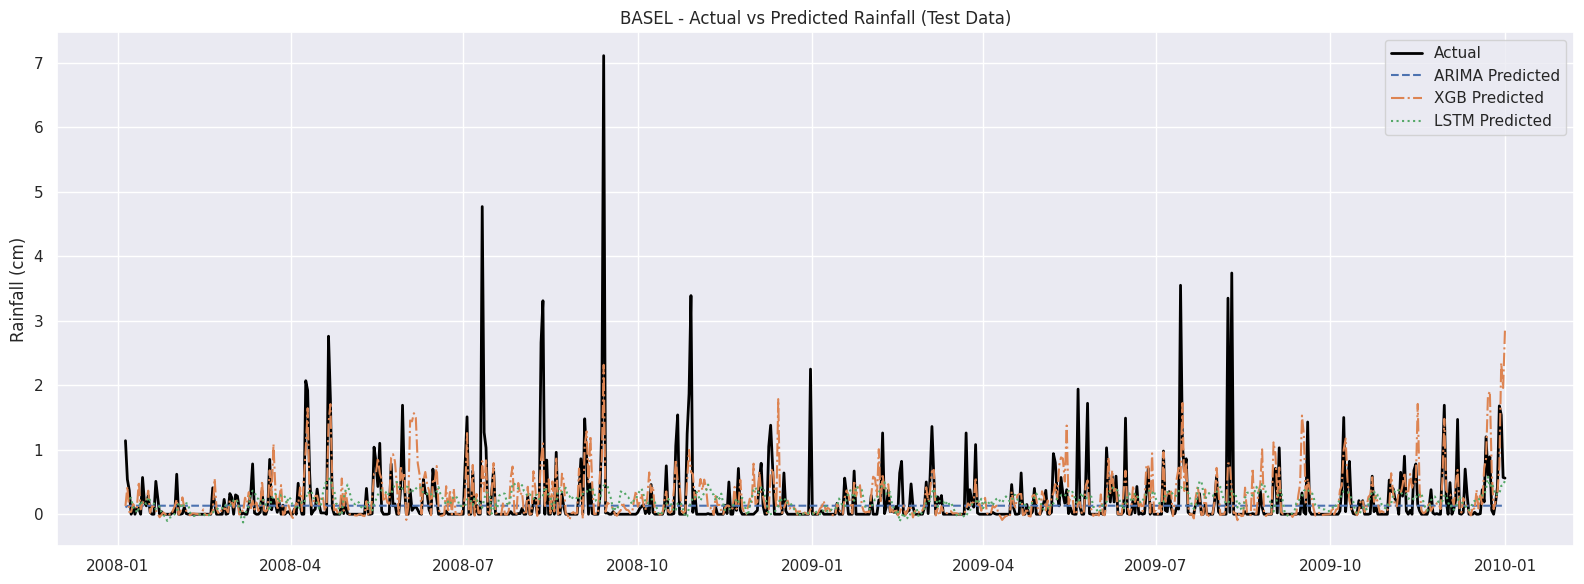

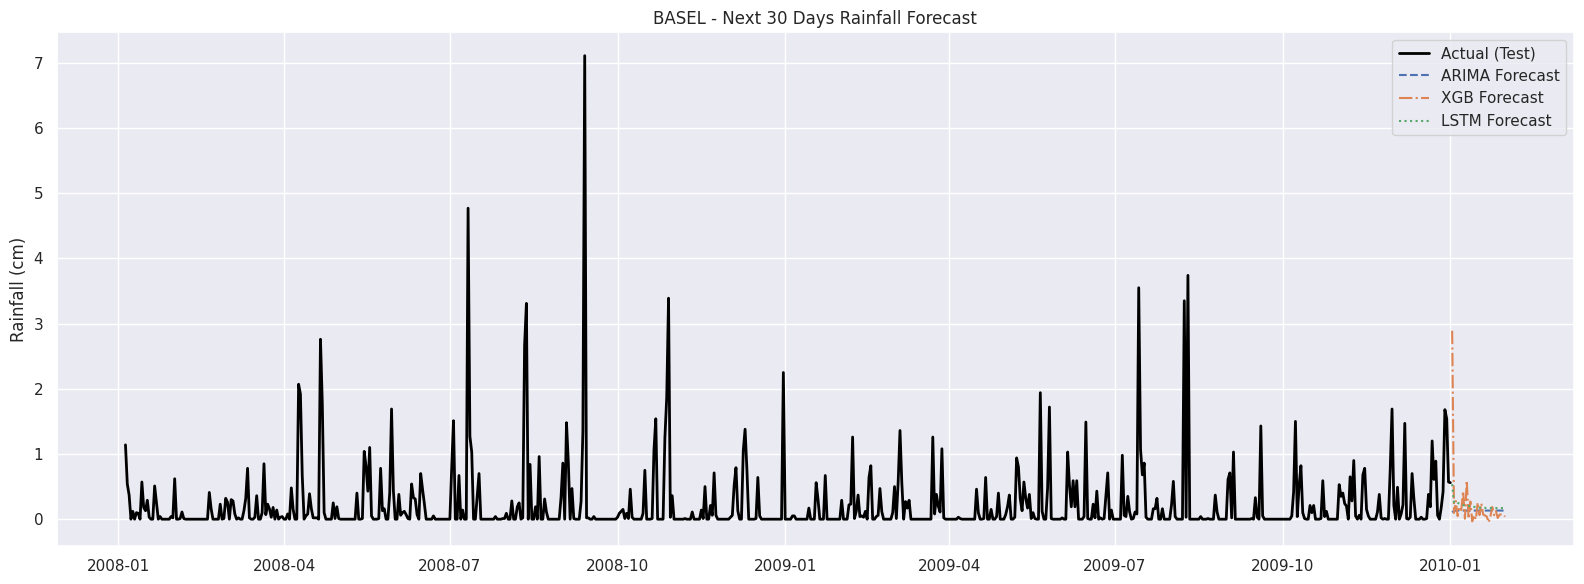

{'Station': 'BASEL',
 'ARIMA_RMSE': np.float64(0.5678307952552428),
 'ARIMA_MAE': 0.2622397266017851,
 'XGB_RMSE': np.float64(0.4851353448907799),
 'XGB_MAE': 0.23205280283703253,
 'LSTM_RMSE': np.float64(0.5570721674990453),
 'LSTM_MAE': 0.29440798917225974}

In [ ]:
run_forecast_pipeline("BASEL", future_days=30)

Stations detected: ['BASEL', 'DE', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'MAASTRICHT', 'MALMO', 'MUENCHEN', 'SONNBLICK', 'TOURS']

 Processing station: BASEL

  Running Forecasting Pipeline for: BASEL
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

  Model Performance:
ARIMA   → RMSE=0.568, MAE=0.262
XGBoost → RMSE=0.485, MAE=0.232
LSTM    → RMSE=0.554, MAE=0.313


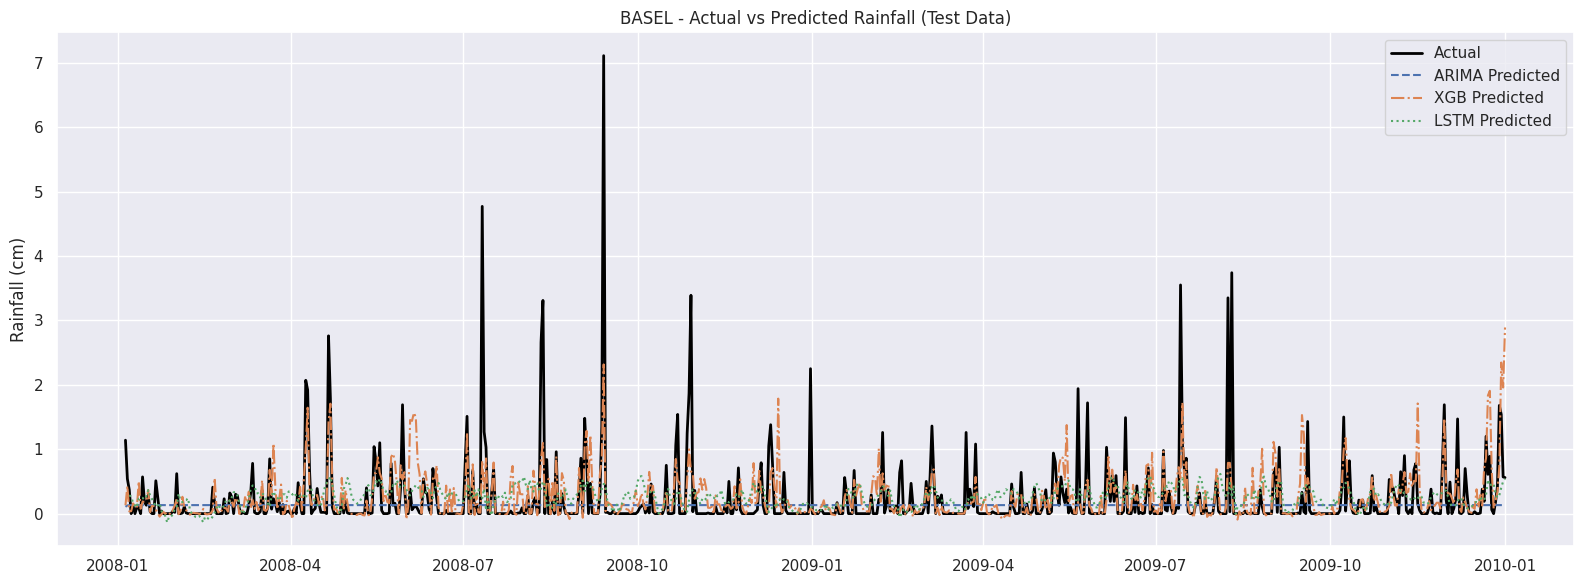

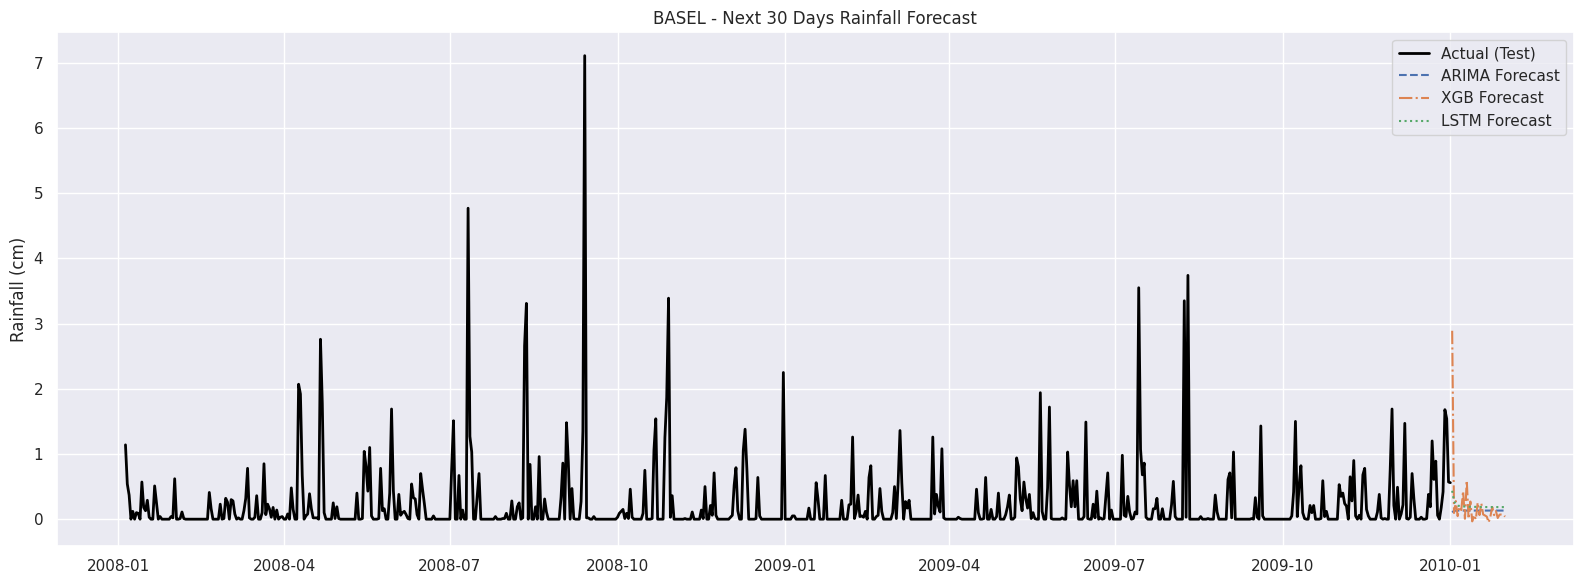


 Processing station: DE

  Running Forecasting Pipeline for: DE
 Skipping DE: No precipitation data found!

 Processing station: DRESDEN

  Running Forecasting Pipeline for: DRESDEN
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

  Model Performance:
ARIMA   → RMSE=0.425, MAE=0.242
XGBoost → RMSE=0.379, MAE=0.190
LSTM    → RMSE=0.433, MAE=0.255


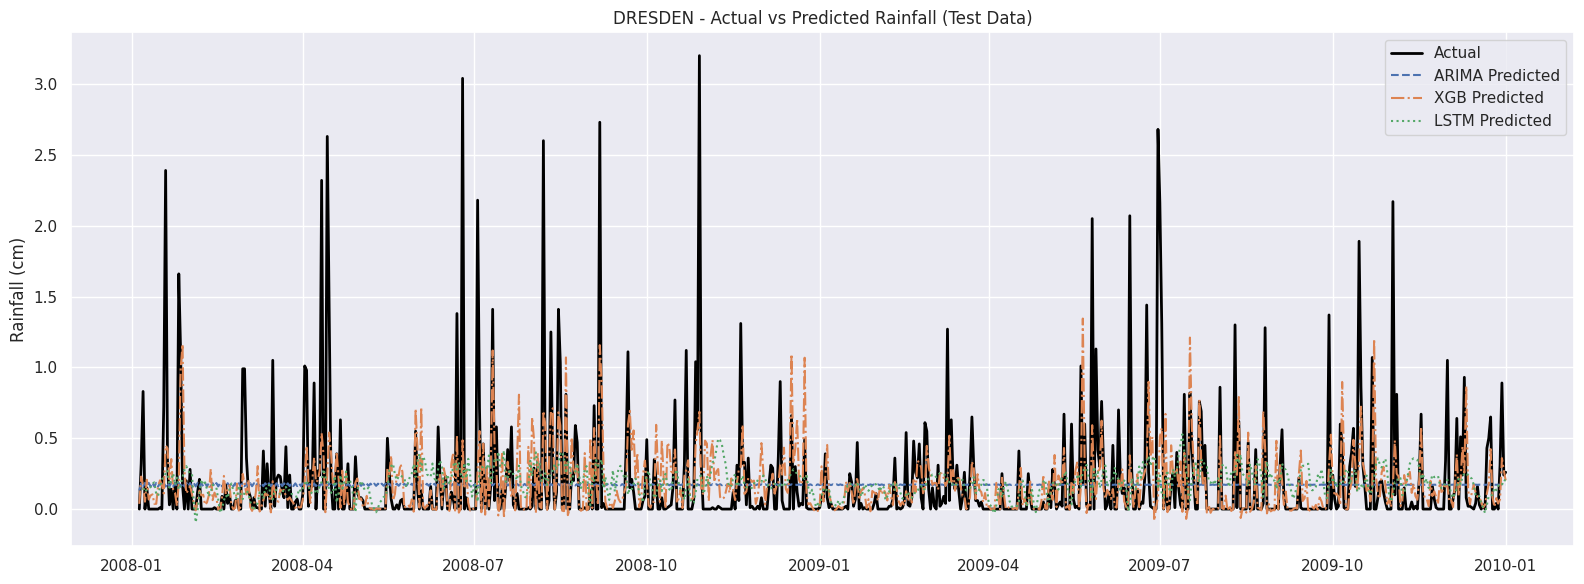

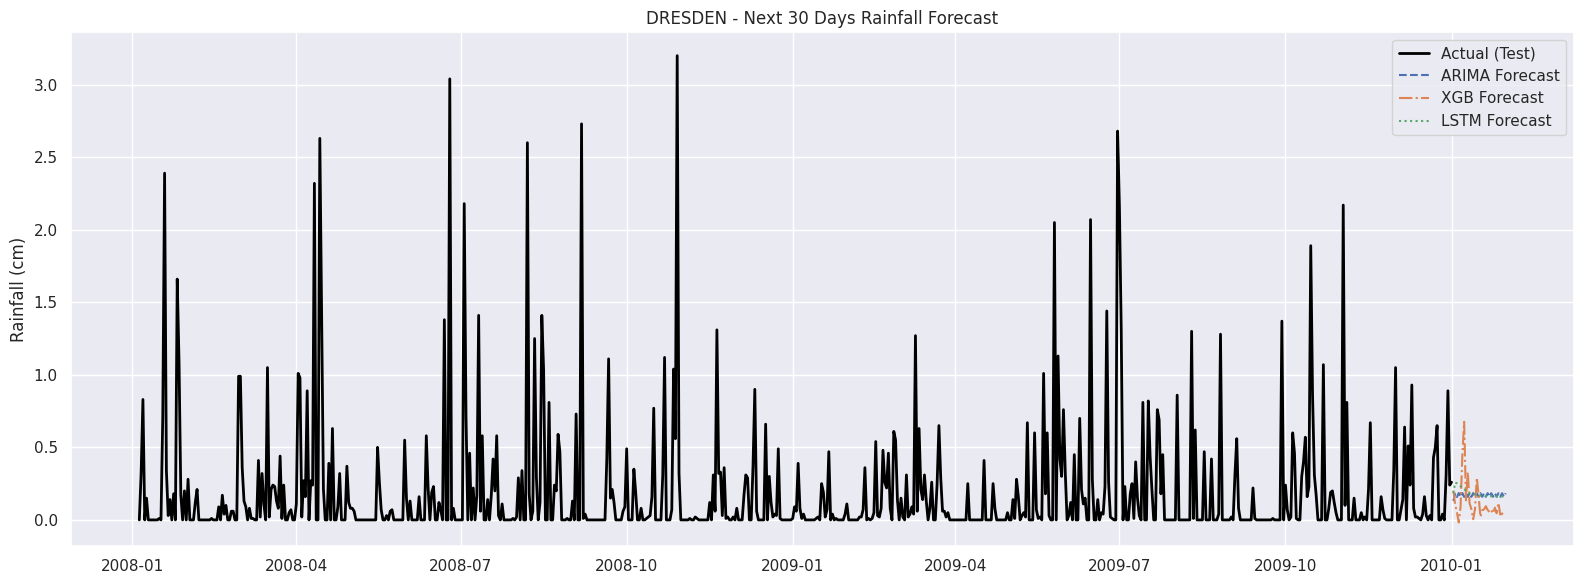


 Processing station: DUSSELDORF

  Running Forecasting Pipeline for: DUSSELDORF
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

  Model Performance:
ARIMA   → RMSE=0.493, MAE=0.290
XGBoost → RMSE=0.450, MAE=0.223
LSTM    → RMSE=0.494, MAE=0.273


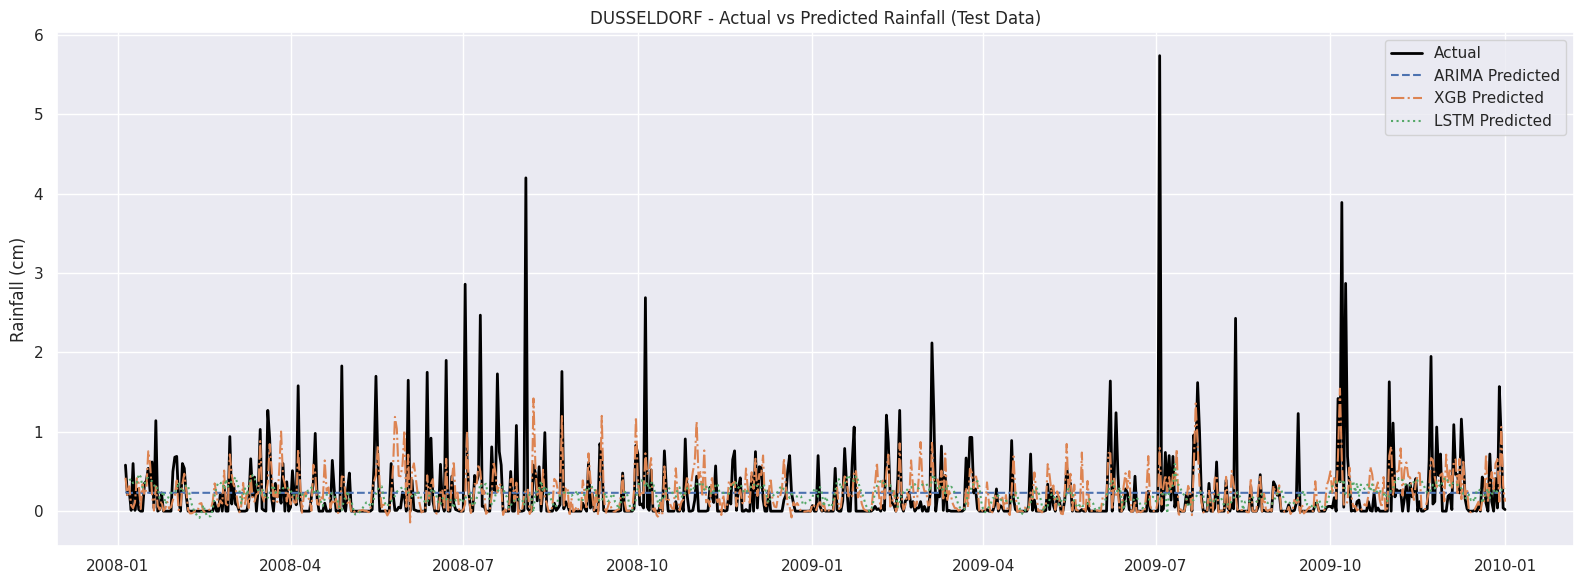

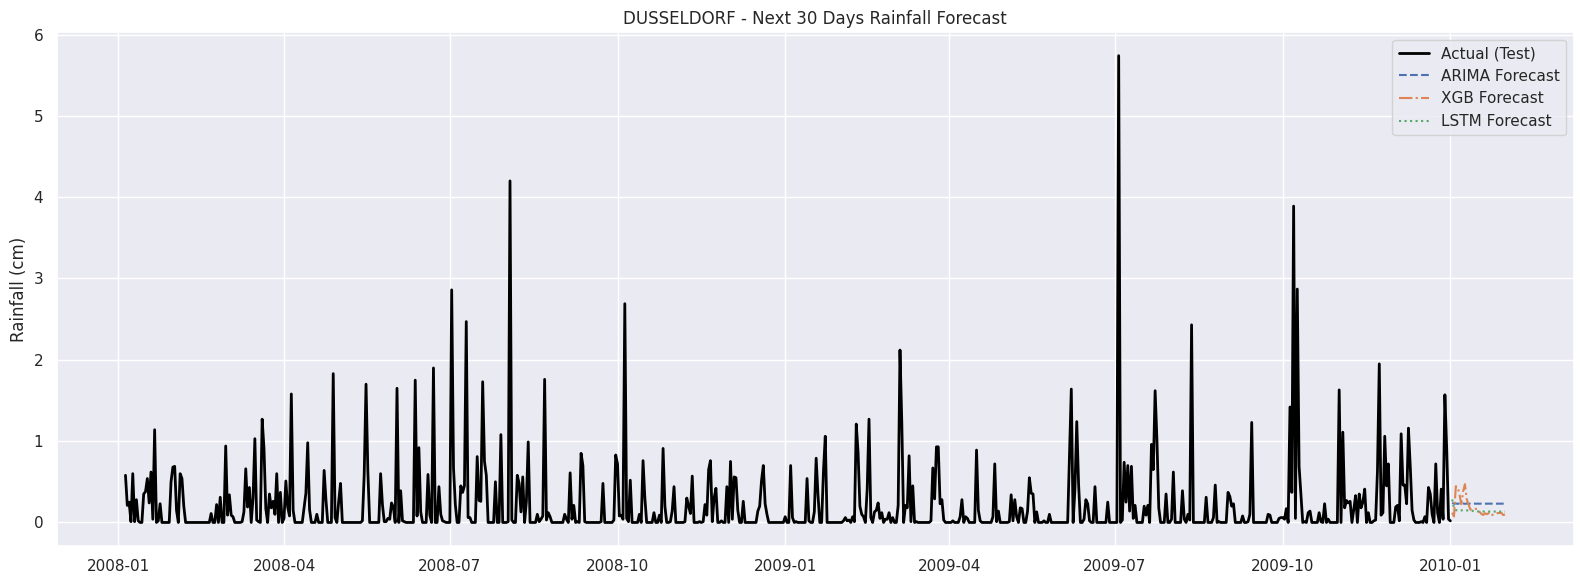


 Processing station: HEATHROW

  Running Forecasting Pipeline for: HEATHROW
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

  Model Performance:
ARIMA   → RMSE=0.388, MAE=0.241
XGBoost → RMSE=0.343, MAE=0.184
LSTM    → RMSE=0.385, MAE=0.217


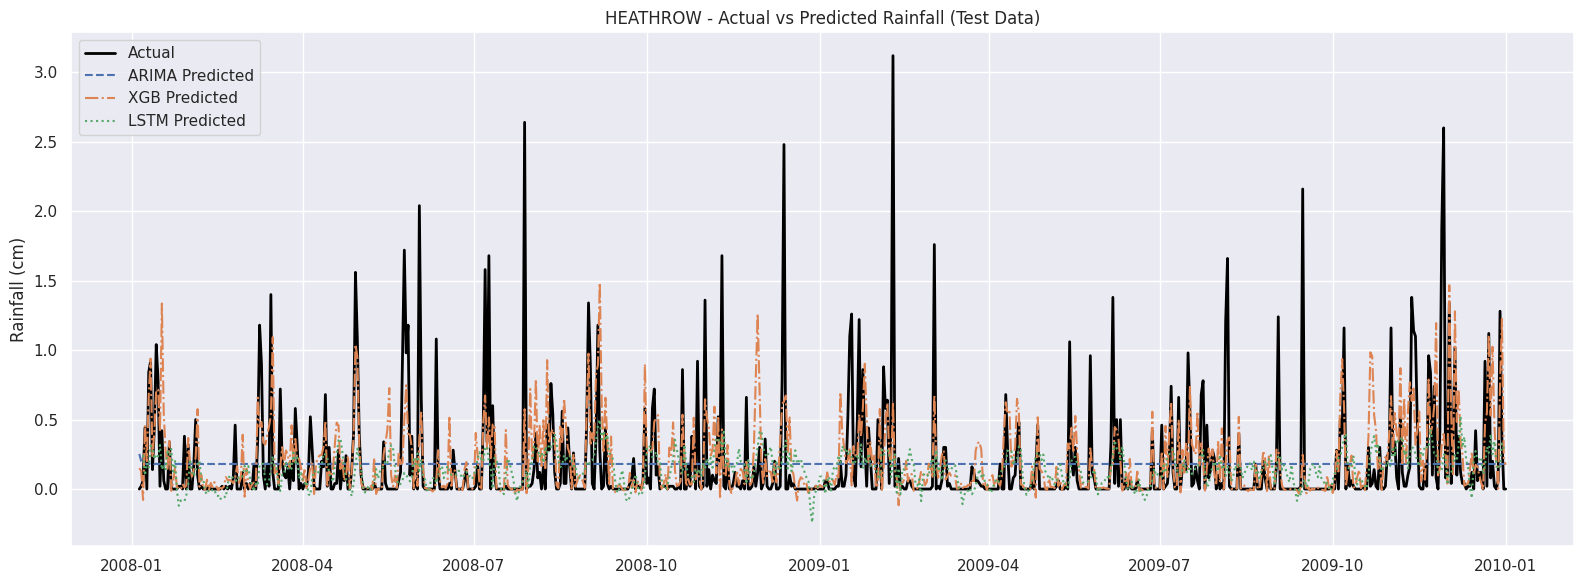

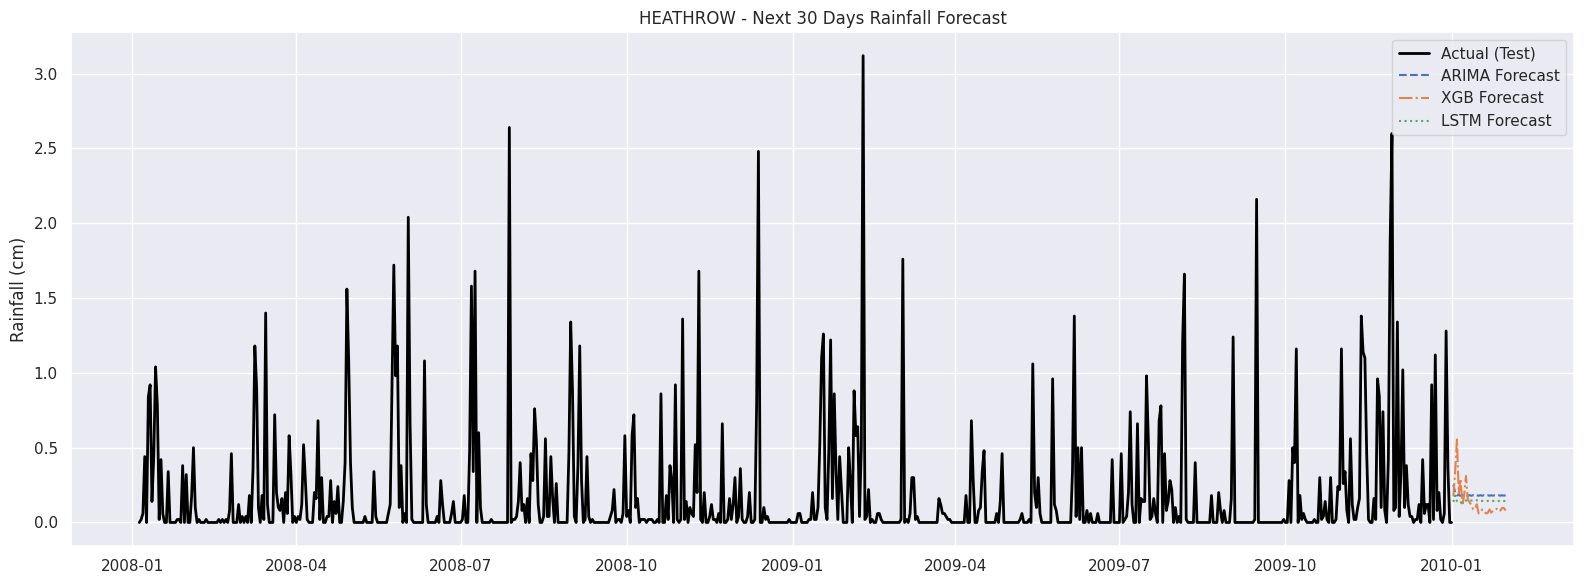


 Processing station: KASSEL

  Running Forecasting Pipeline for: KASSEL
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

  Model Performance:
ARIMA   → RMSE=0.364, MAE=0.249
XGBoost → RMSE=0.345, MAE=0.199
LSTM    → RMSE=0.369, MAE=0.265


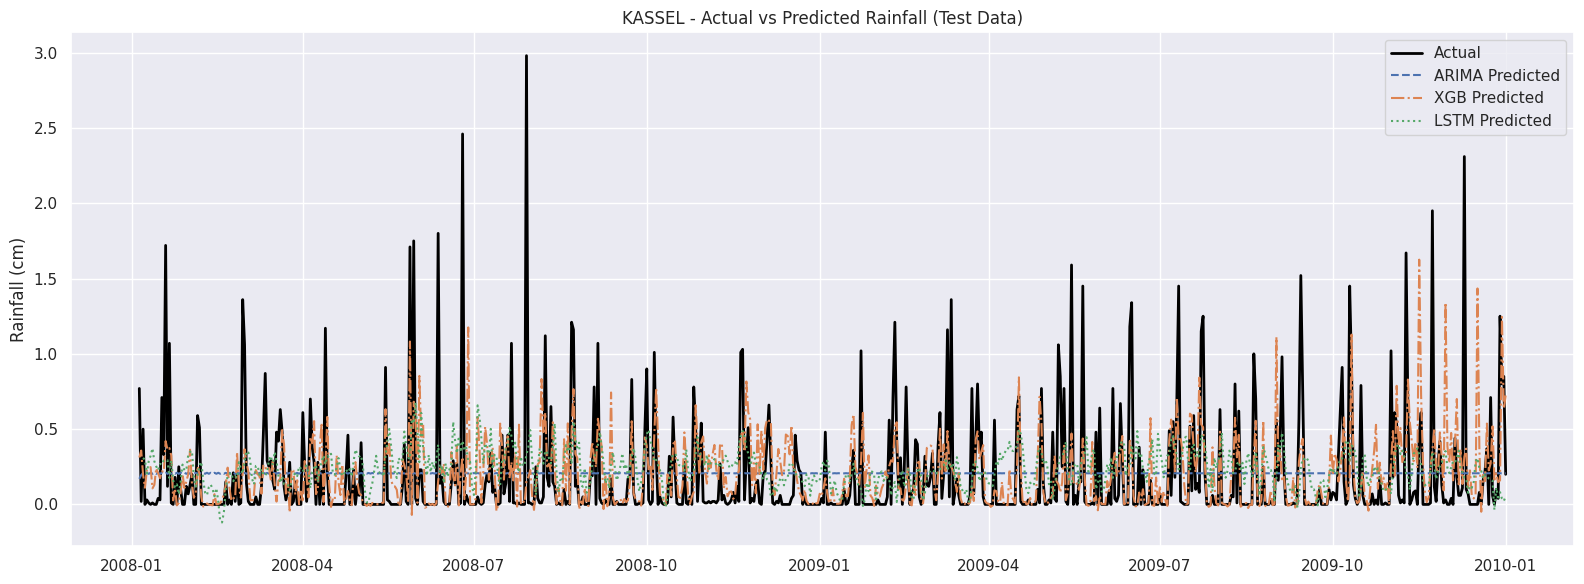

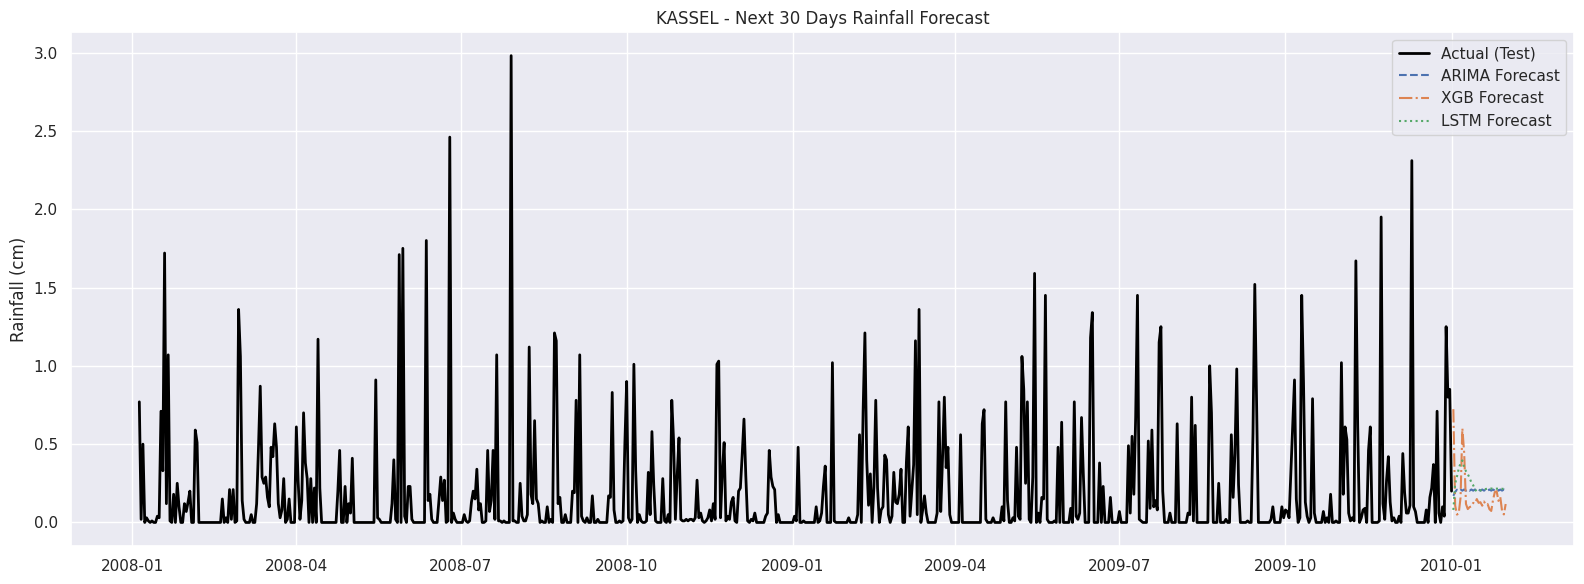


 Processing station: MAASTRICHT

  Running Forecasting Pipeline for: MAASTRICHT
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

  Model Performance:
ARIMA   → RMSE=0.446, MAE=0.288
XGBoost → RMSE=0.361, MAE=0.207
LSTM    → RMSE=0.439, MAE=0.277


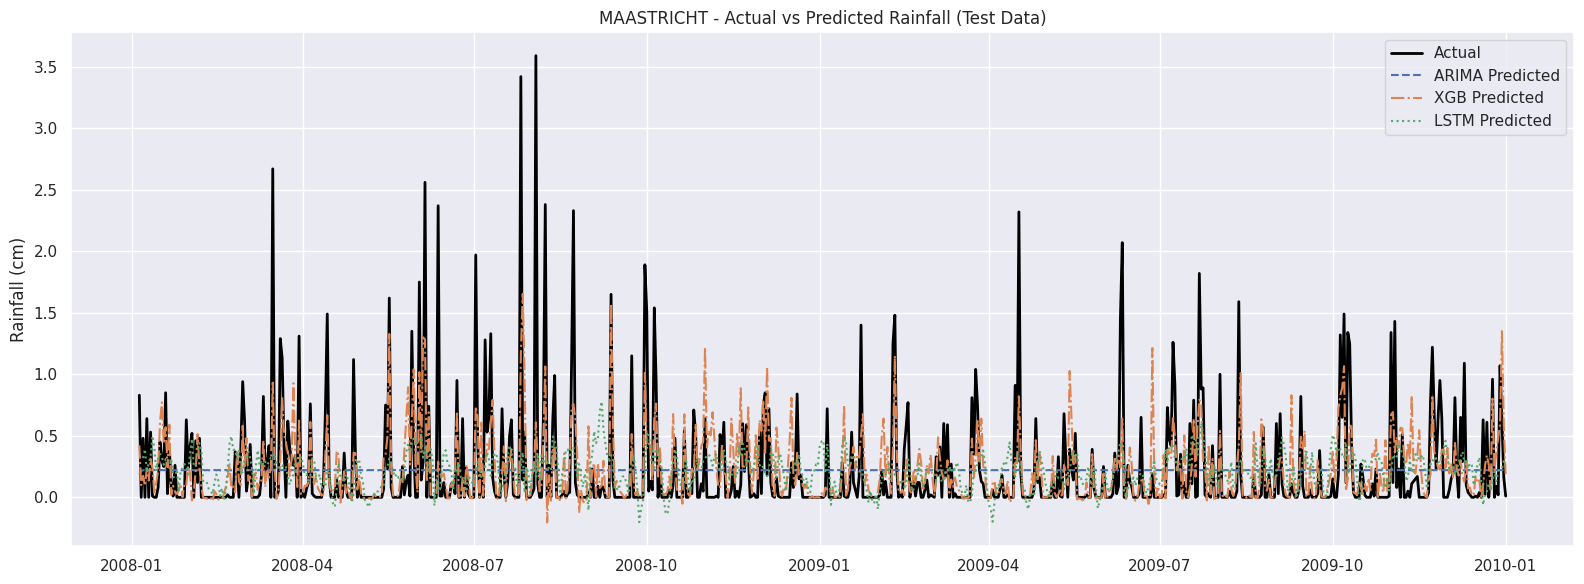

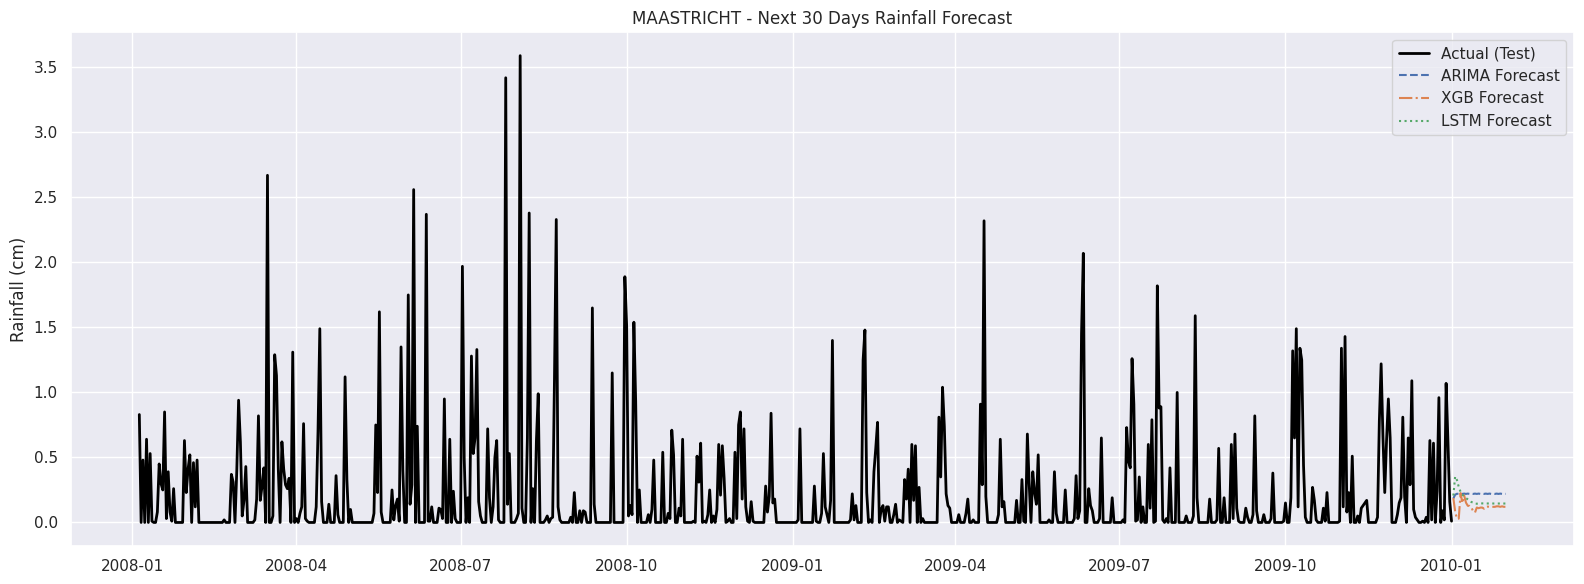


 Processing station: MALMO

  Running Forecasting Pipeline for: MALMO
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

  Model Performance:
ARIMA   → RMSE=0.353, MAE=0.232
XGBoost → RMSE=0.361, MAE=0.199
LSTM    → RMSE=0.354, MAE=0.209


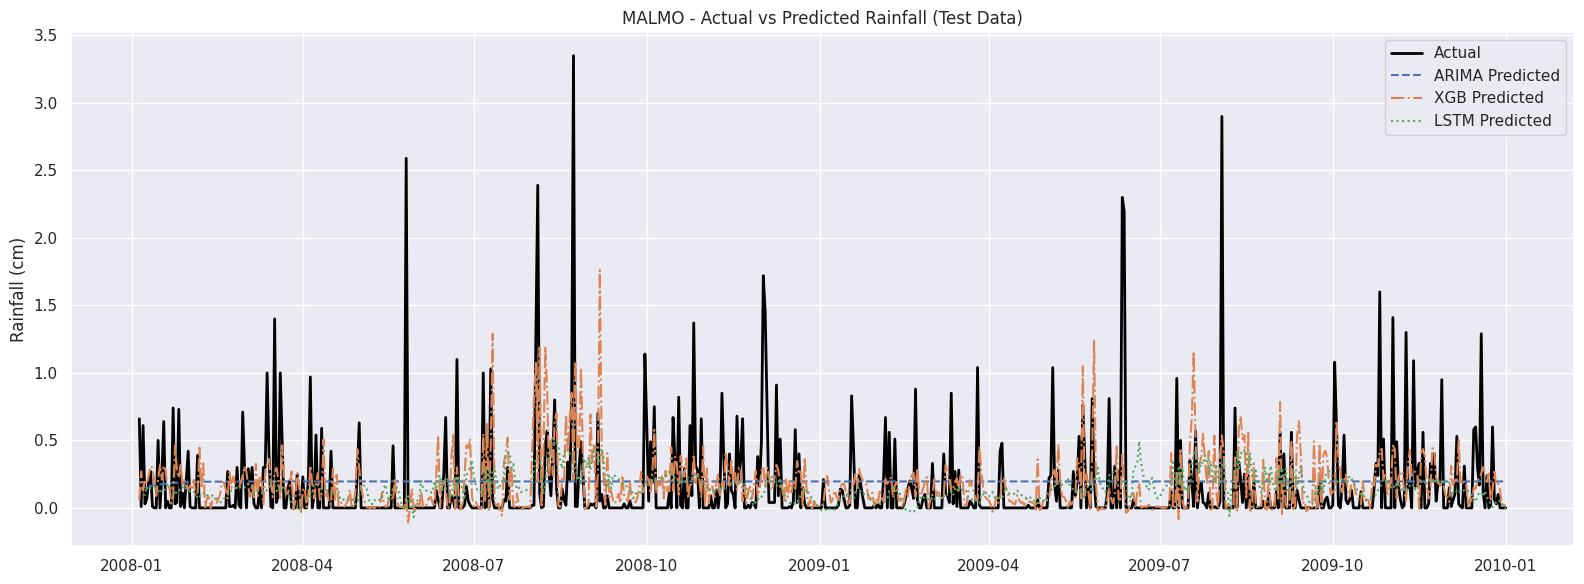

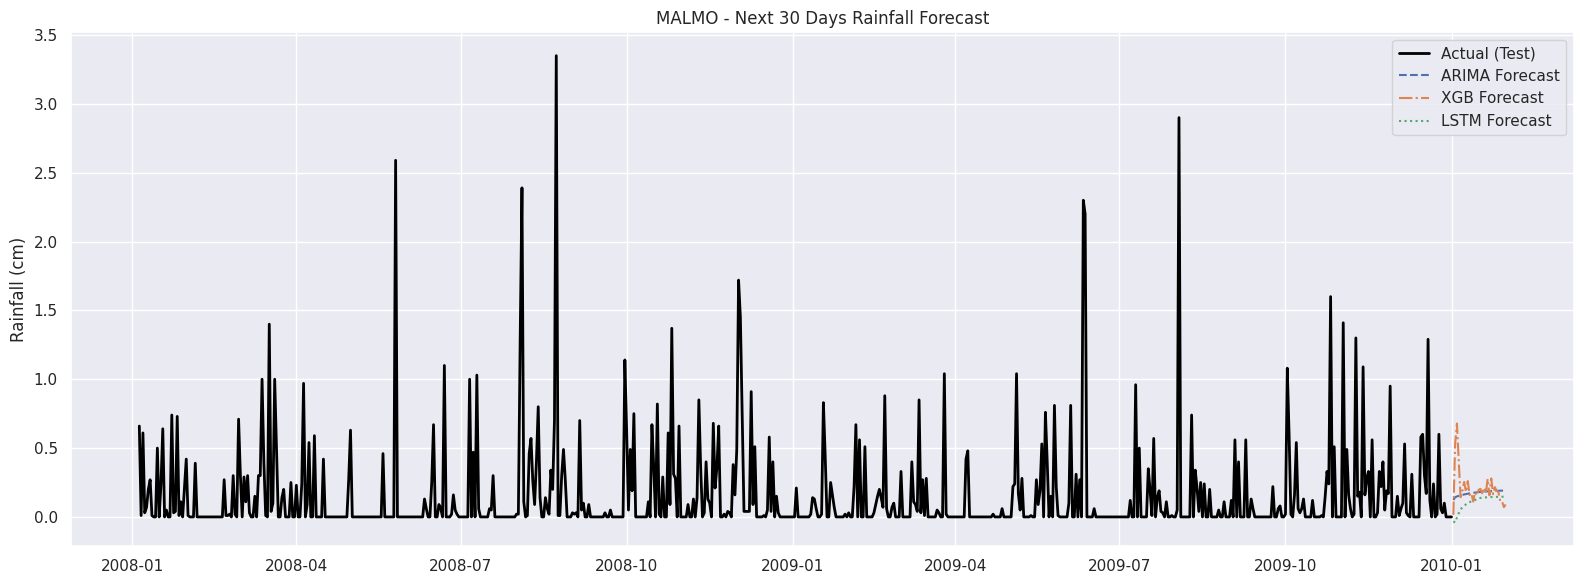


 Processing station: MUENCHEN

  Running Forecasting Pipeline for: MUENCHEN
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

  Model Performance:
ARIMA   → RMSE=0.520, MAE=0.320
XGBoost → RMSE=0.488, MAE=0.244
LSTM    → RMSE=0.516, MAE=0.303


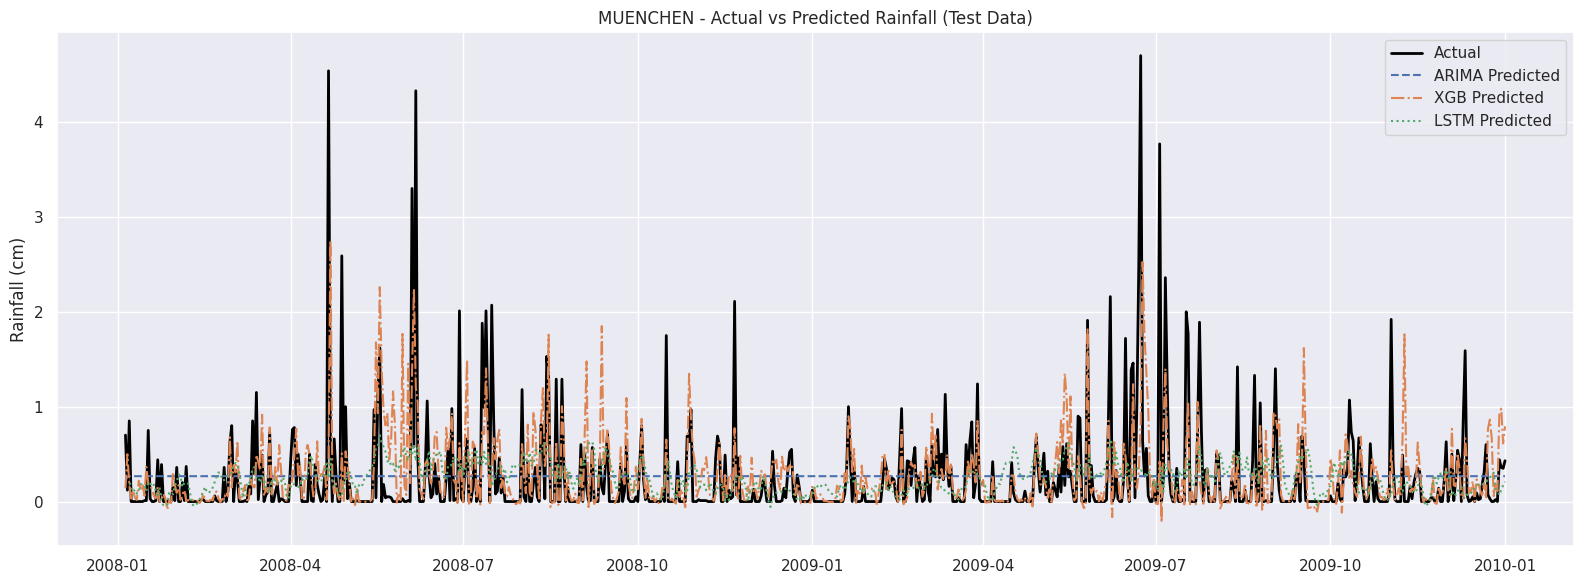

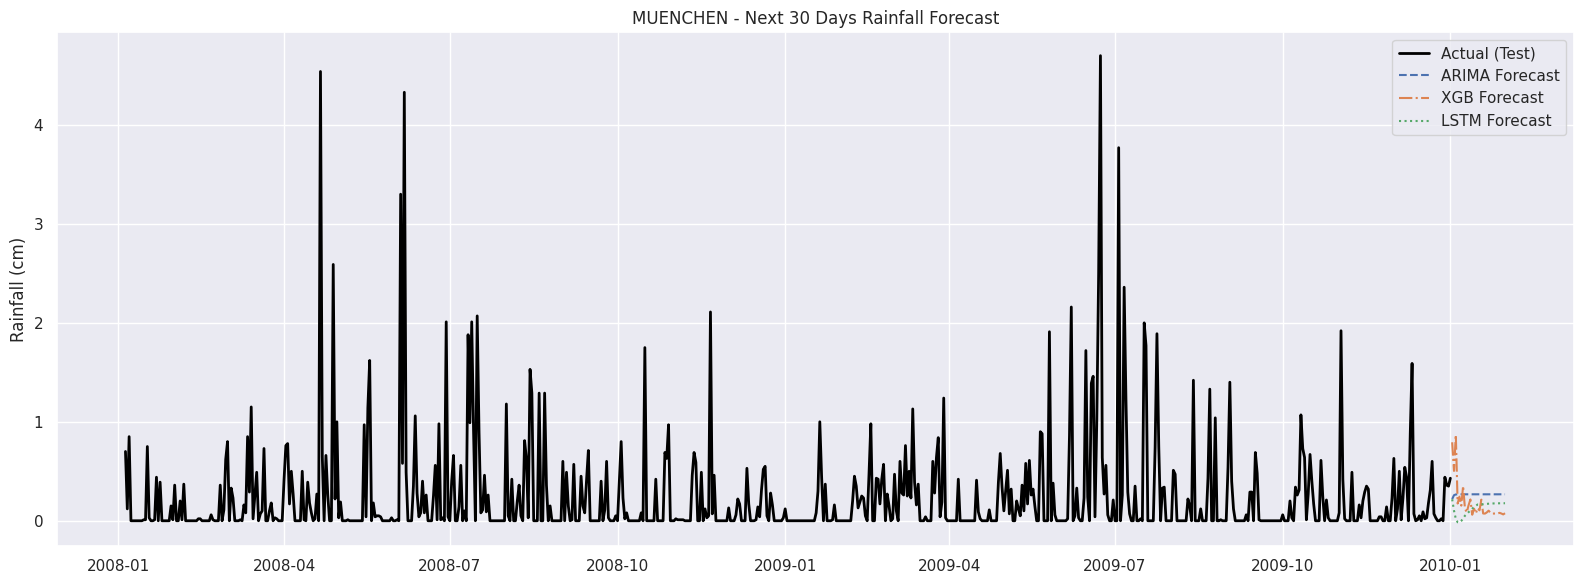


 Processing station: SONNBLICK

  Running Forecasting Pipeline for: SONNBLICK
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

  Model Performance:
ARIMA   → RMSE=0.756, MAE=0.563
XGBoost → RMSE=0.639, MAE=0.432
LSTM    → RMSE=0.754, MAE=0.565


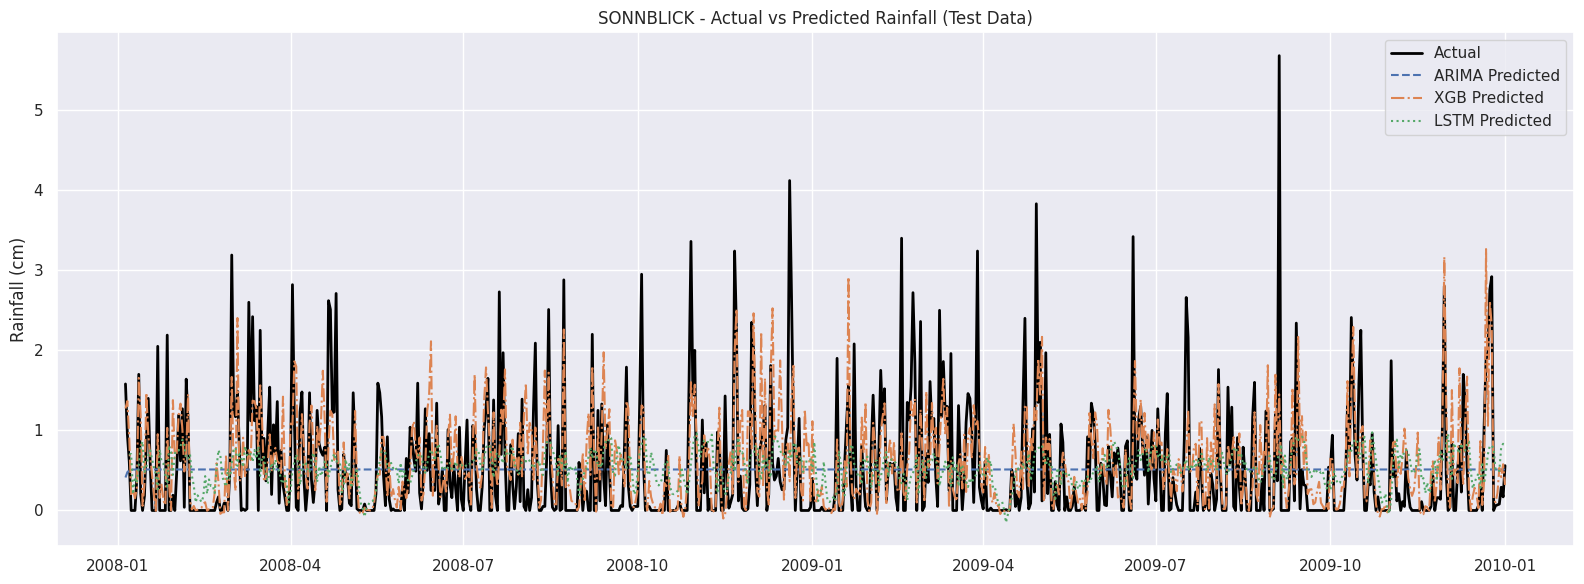

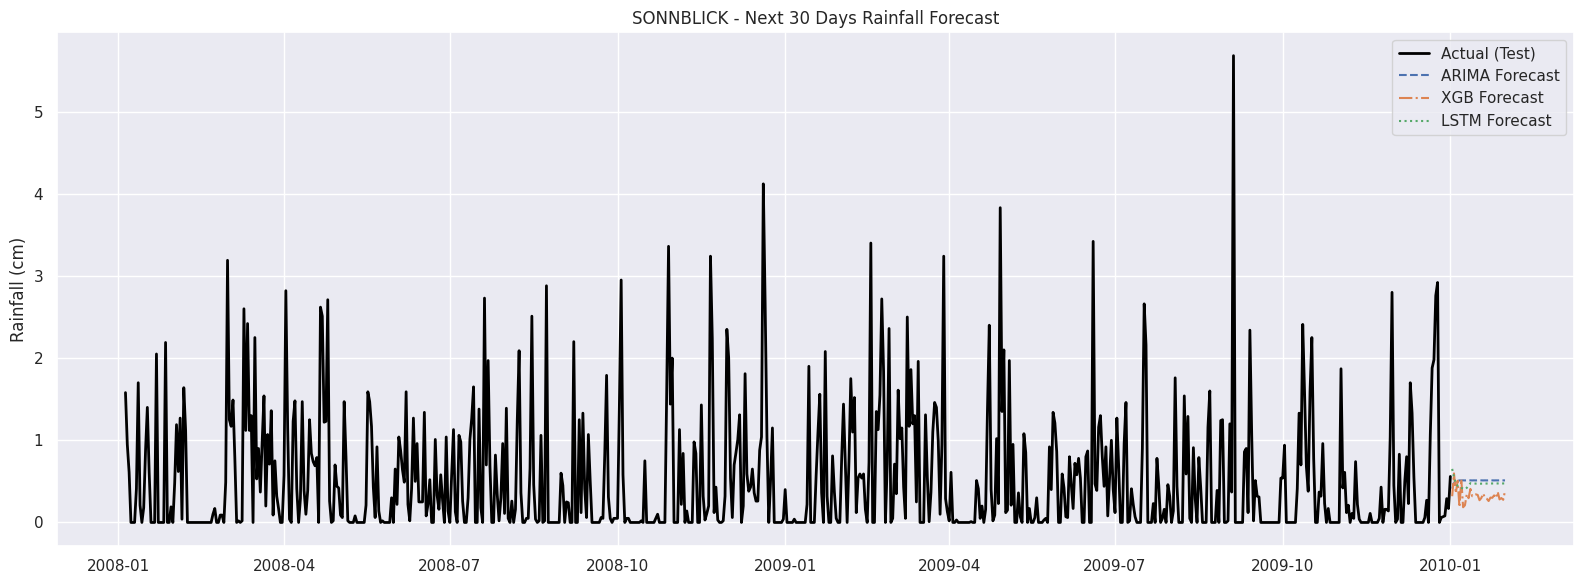


 Processing station: TOURS

  Running Forecasting Pipeline for: TOURS
 Train samples: 2912, Test samples: 728

 Training ARIMA...
 Training XGBoost...
 Training LSTM... (this may take some seconds)
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

  Model Performance:
ARIMA   → RMSE=0.419, MAE=0.238
XGBoost → RMSE=0.383, MAE=0.171
LSTM    → RMSE=0.413, MAE=0.247


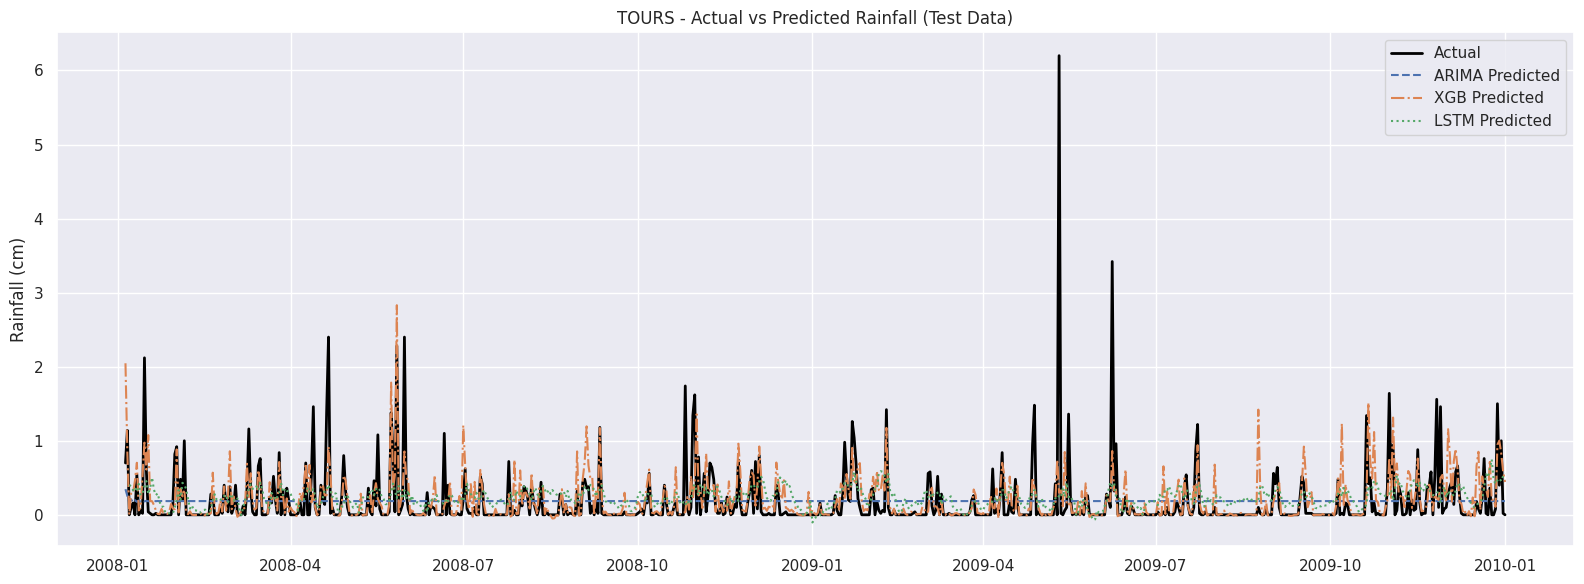

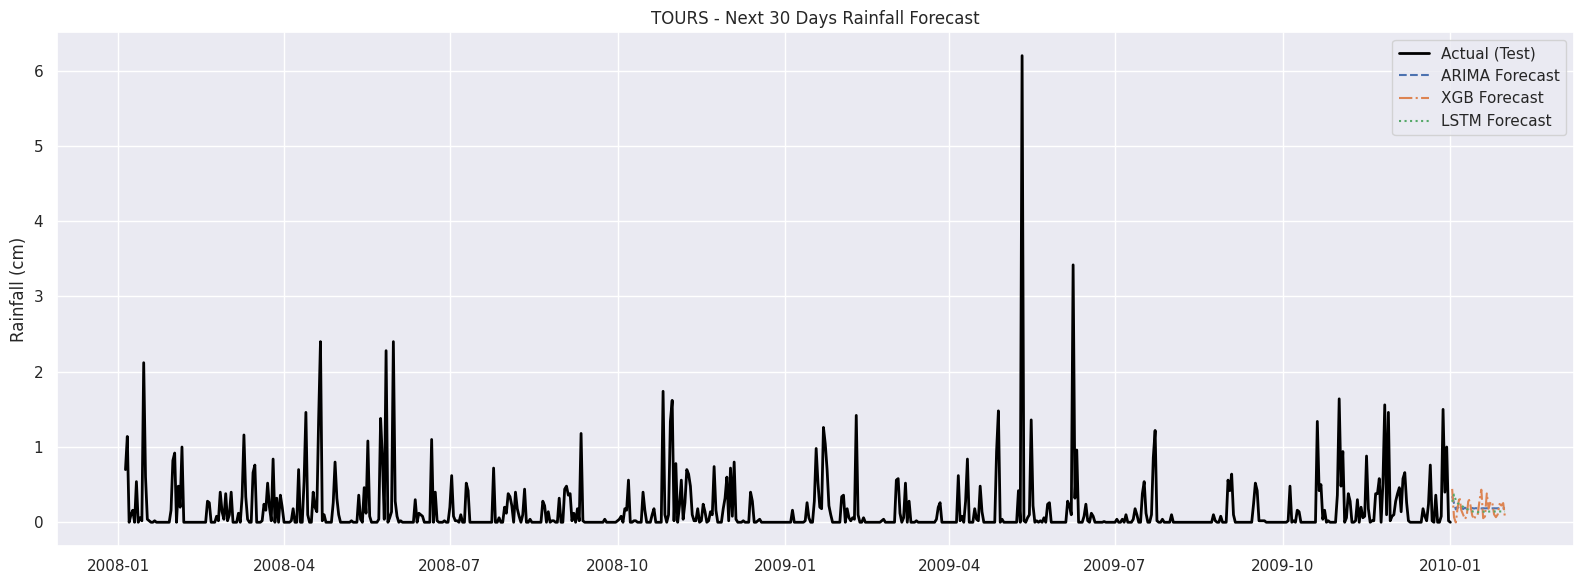


 Forecasting completed for all available stations.


,Station,ARIMA_RMSE,ARIMA_MAE,XGB_RMSE,XGB_MAE,LSTM_RMSE,LSTM_MAE
0,BASEL,0.568,0.262,0.485,0.232,0.554,0.313
1,DRESDEN,0.425,0.242,0.379,0.190,0.433,0.255
2,DUSSELDORF,0.493,0.290,0.450,0.223,0.494,0.273
3,HEATHROW,0.388,0.241,0.343,0.184,0.385,0.217
4,KASSEL,0.364,0.249,0.345,0.199,0.369,0.265
5,MAASTRICHT,0.446,0.288,0.361,0.207,0.439,0.277
6,MALMO,0.353,0.232,0.361,0.199,0.354,0.209
7,MUENCHEN,0.520,0.320,0.488,0.244,0.516,0.303
8,SONNBLICK,0.756,0.563,0.639,0.432,0.754,0.565
9,TOURS,0.419,0.238,0.383,0.171,0.413,0.247


In [ ]:
# =====================================================================
# Run Forecasting Pipeline for ALL Stations & Collect Metrics
# =====================================================================

results_list = []

# Detect stations from precipitation columns
stations = sorted(list(set([c.split('_')[0] for c in df.columns if c.endswith("_precipitation")])))

print("Stations detected:", stations)

for st in stations:
    print("\n========================================")
    print(f" Processing station: {st}")
    print("========================================")

    try:
        res = run_forecast_pipeline(station_name=st, future_days=30)
        if res is not None:
            results_list.append(res)
    except Exception as e:
        print(f" Error with station {st}: {e}")

# Build DataFrame from results
results_df = pd.DataFrame(results_list)
print("\n Forecasting completed for all available stations.")
display(results_df)


In [ ]:
# ============================================================
#  XGBoost Feature Importance Visualization (Single Station)
# ============================================================

def plot_xgb_feature_importance(station_name="BASEL"):

    print(f"\n Plotting XGBoost Feature Importance for: {station_name}")

    # Select station cols
    target = f"{station_name}_precipitation"
    station_cols = [c for c in df.columns if c.startswith(station_name + "_")]
    data = df[station_cols].dropna().copy()

    if target not in data.columns:
        print(f" No precipitation column for {station_name}")
        return

    # Add lag features to match forecasting pipeline
    for lag in [1, 3, 7, 14]:
        data[f"{target}_lag{lag}"] = data[target].shift(lag)
    data.dropna(inplace=True)

    # Train/test split
    total_len = len(data)
    train_end = int(total_len * 0.8)

    train = data.iloc[:train_end]
    X_train, y_train = train.drop(columns=[target]), train[target]

    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    # Train XGB
    model = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6)
    model.fit(X_train_s, y_train)

    # Extract importances
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Sort features by importance
    idx = np.argsort(importances)
    sorted_features = feature_names[idx]
    sorted_importances = importances[idx]

    # Plot
    plt.figure(figsize=(10, 10))
    plt.barh(sorted_features, sorted_importances, color="seagreen")
    plt.title(f"XGBoost Feature Importance — {station_name} Rainfall Forecasting")
    plt.xlabel("Importance Score")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()



 Plotting XGBoost Feature Importance for: BASEL


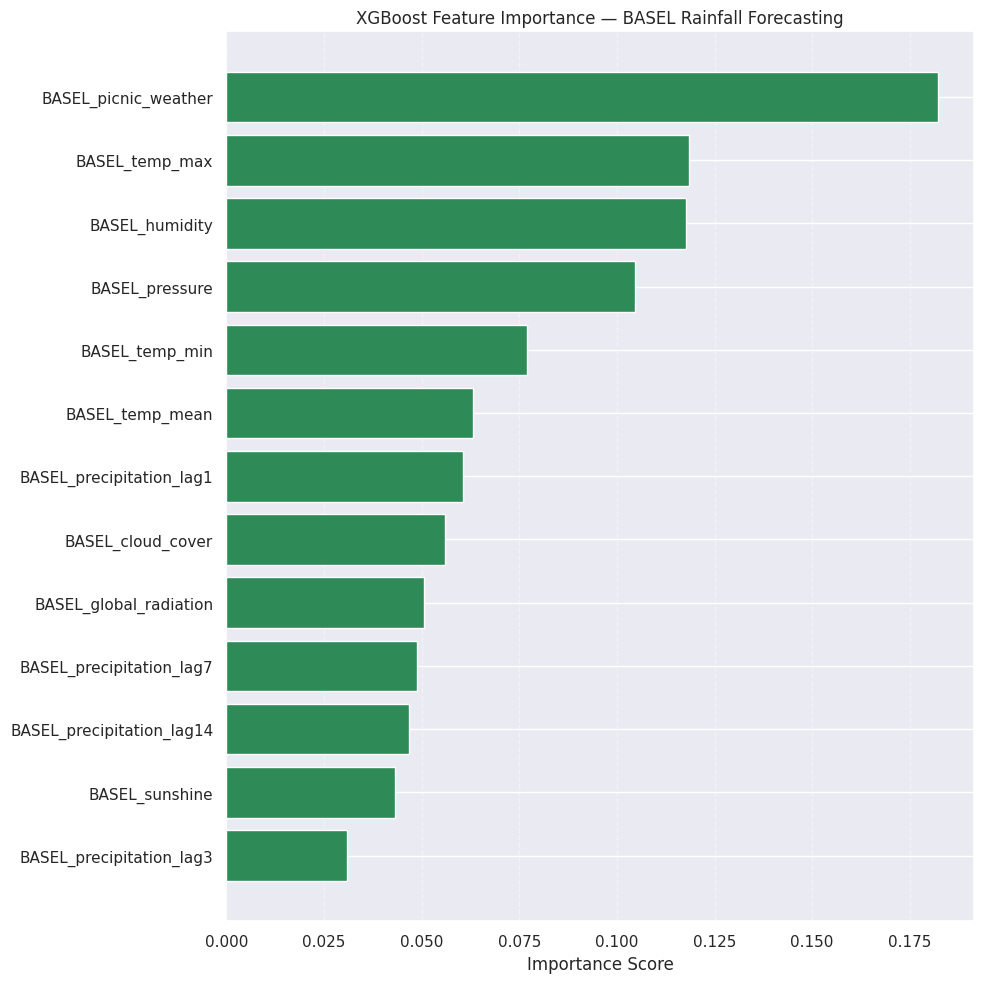


 Plotting XGBoost Feature Importance for: DRESDEN


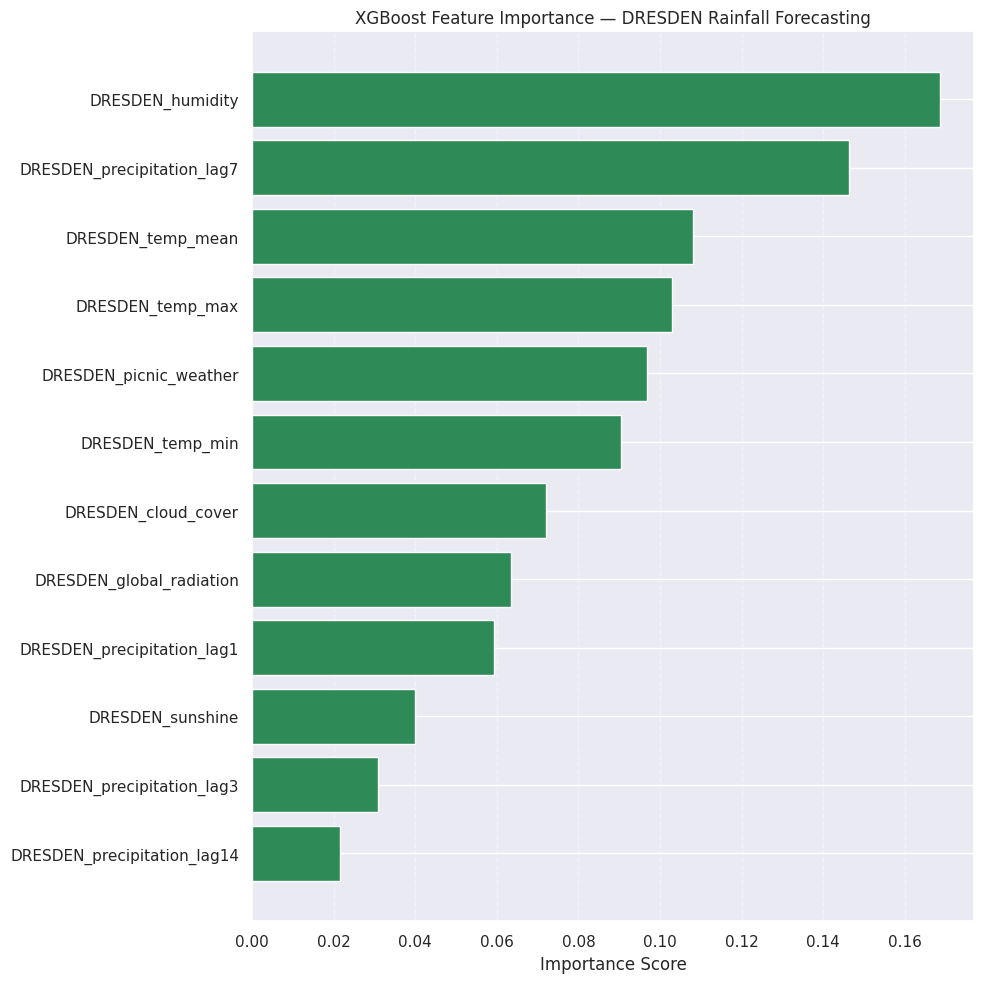


 Plotting XGBoost Feature Importance for: DUSSELDORF


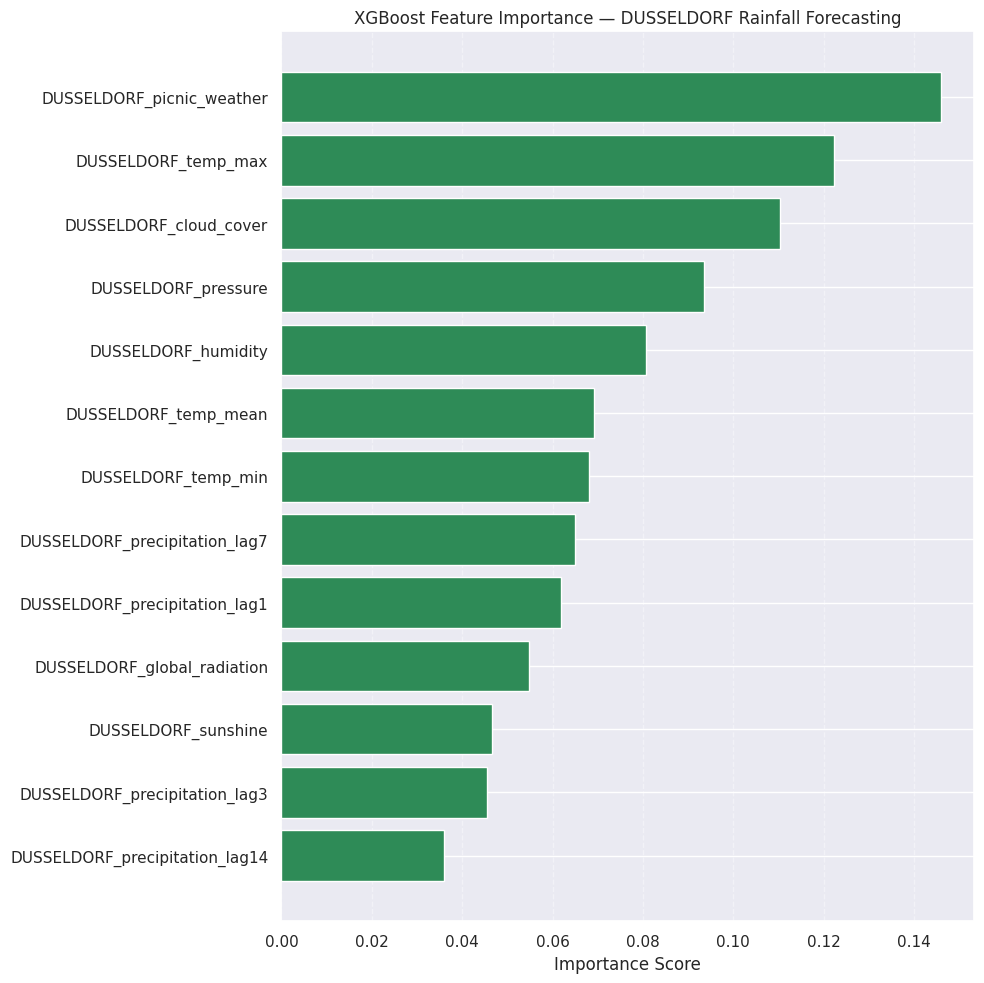


 Plotting XGBoost Feature Importance for: HEATHROW


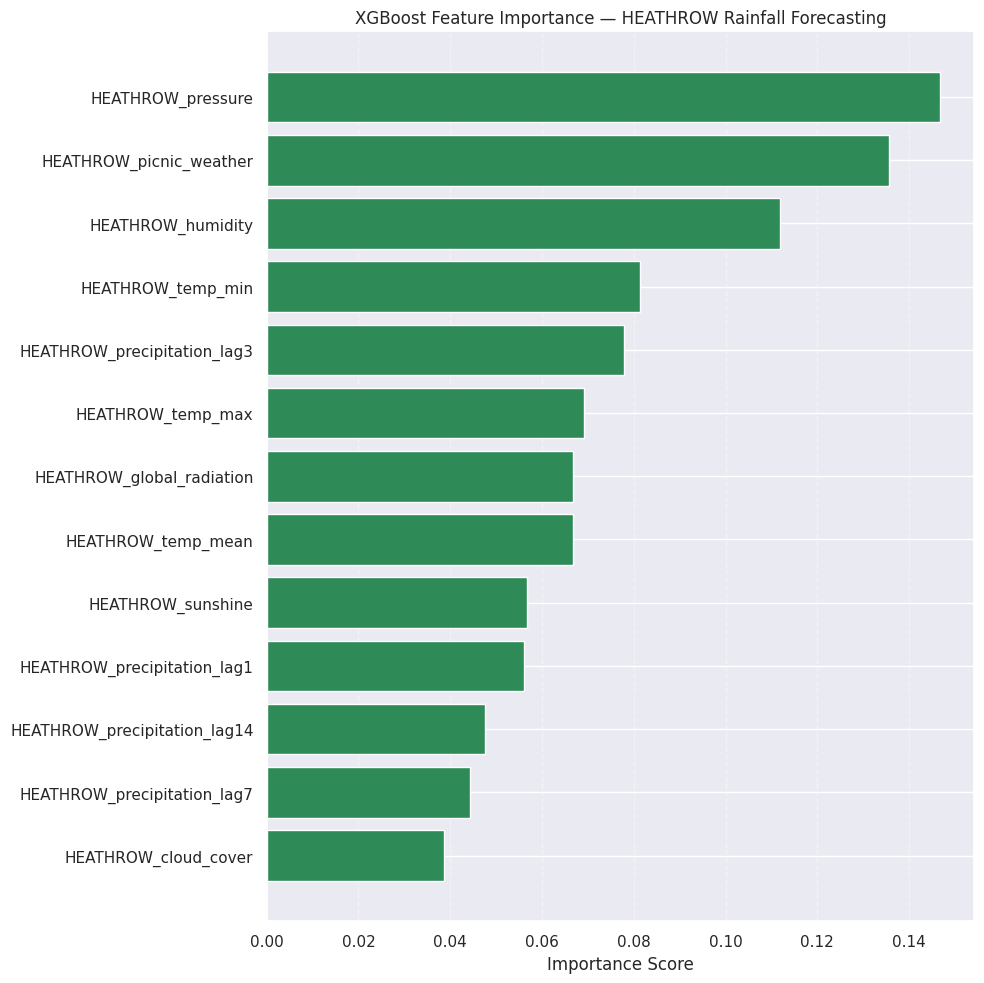


 Plotting XGBoost Feature Importance for: KASSEL


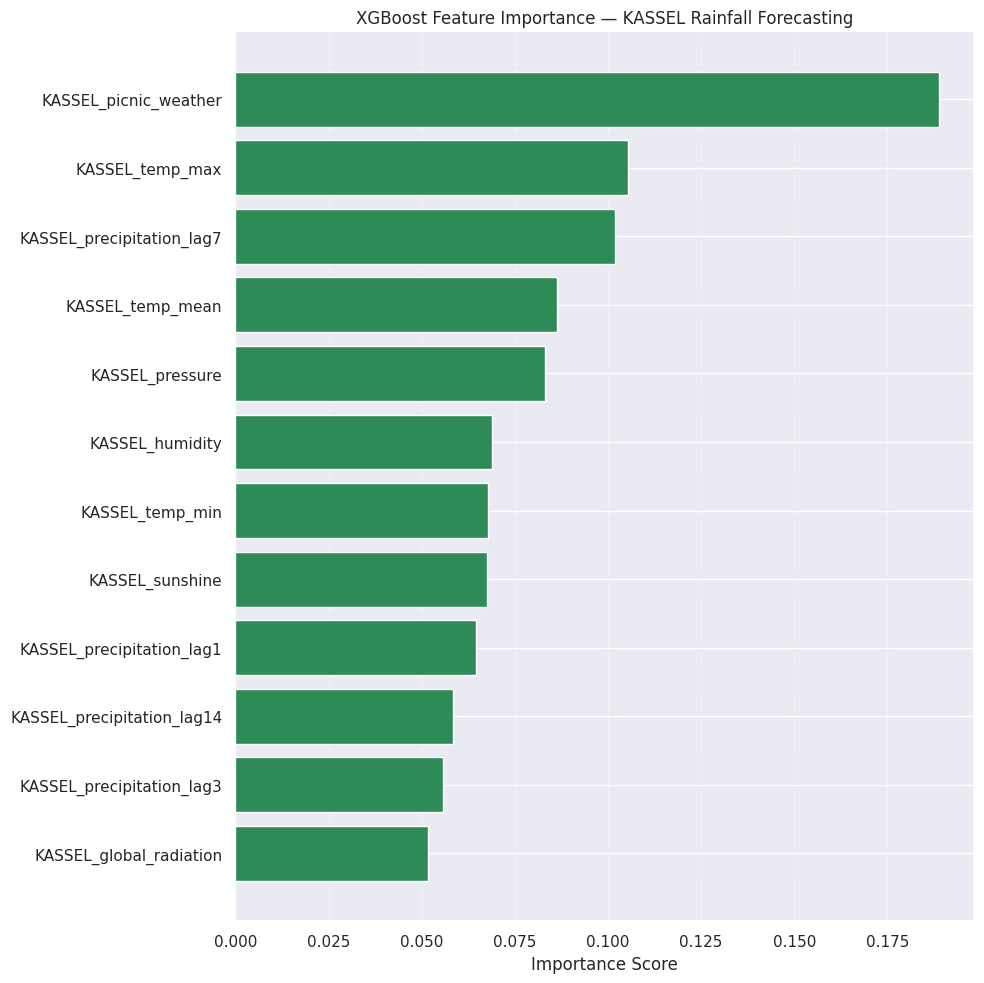


 Plotting XGBoost Feature Importance for: MAASTRICHT


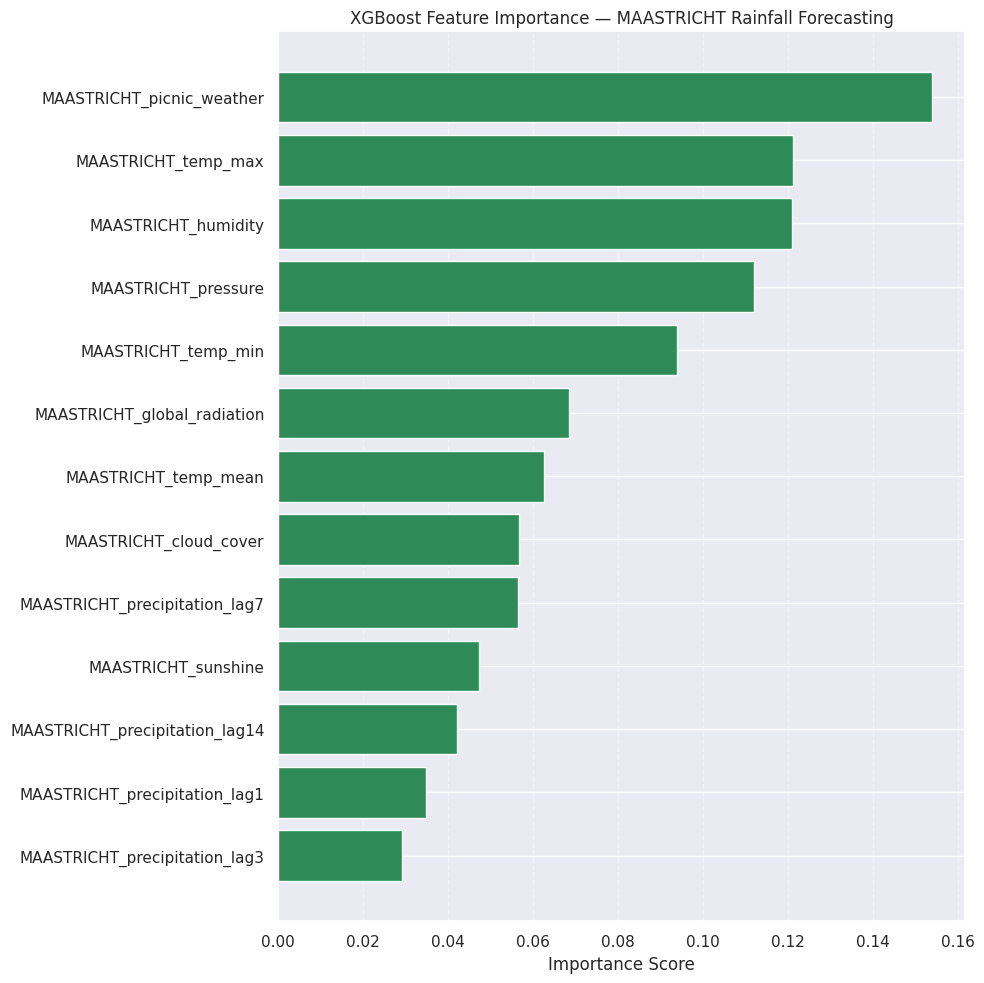


 Plotting XGBoost Feature Importance for: MALMO


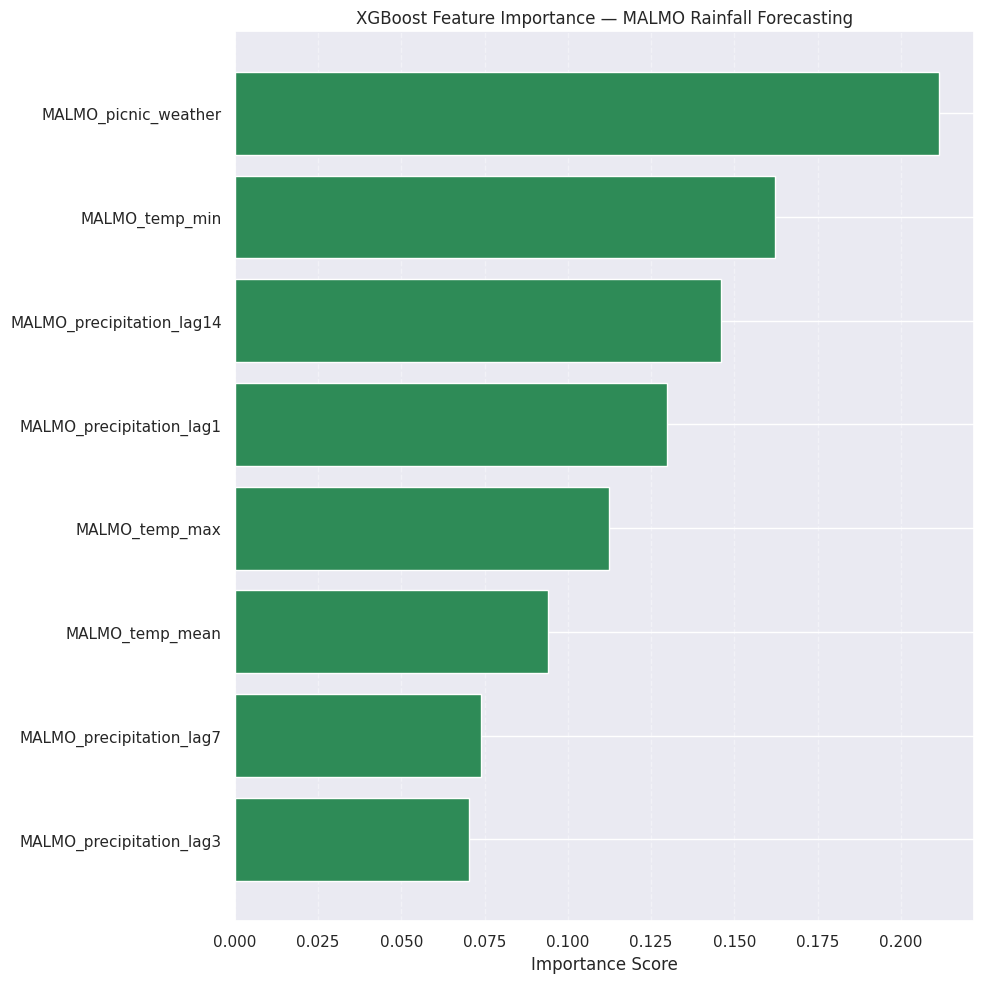


 Plotting XGBoost Feature Importance for: MUENCHEN


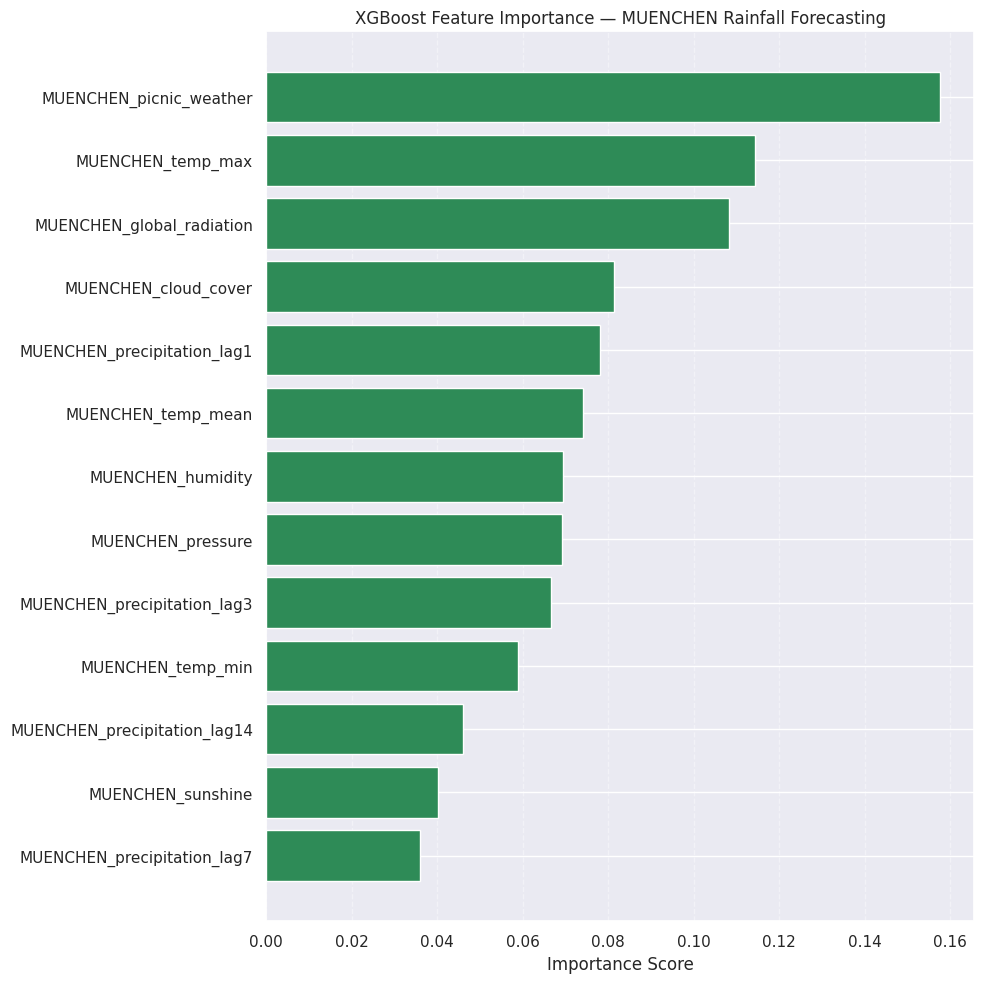


 Plotting XGBoost Feature Importance for: SONNBLICK


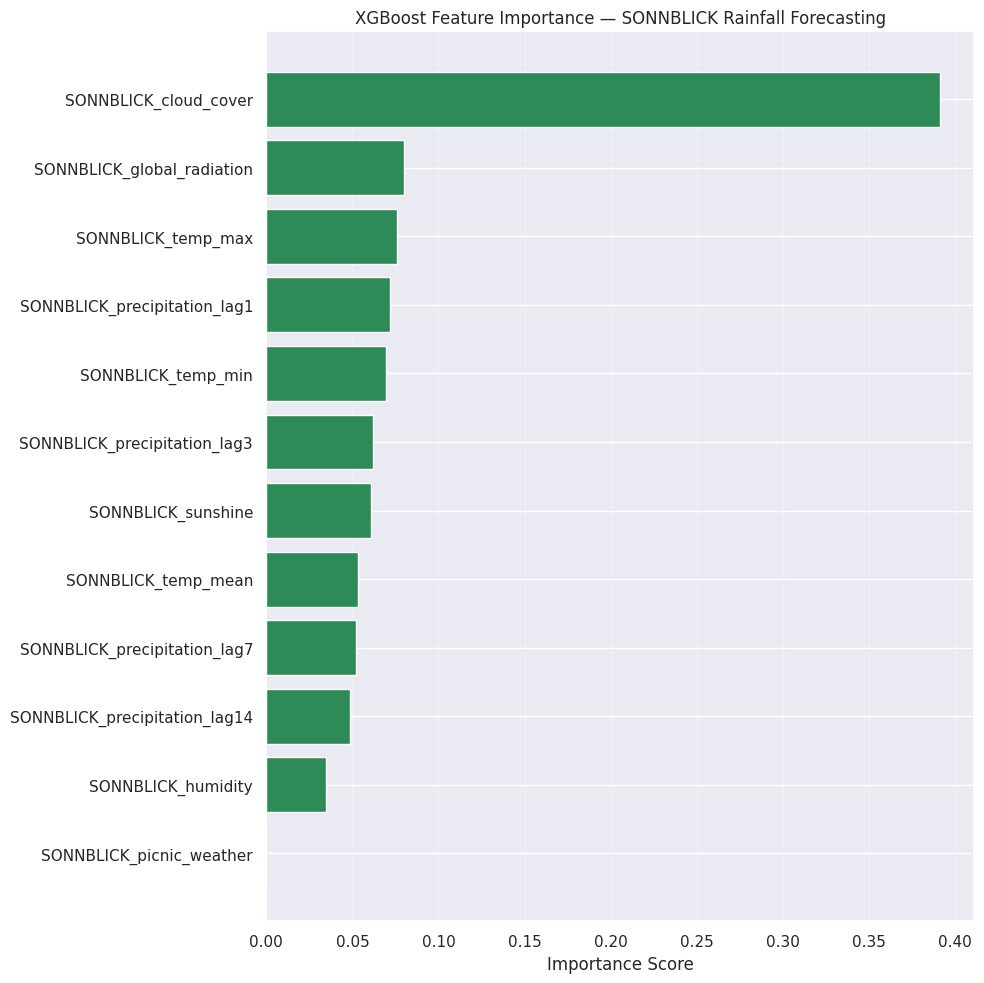


 Plotting XGBoost Feature Importance for: TOURS


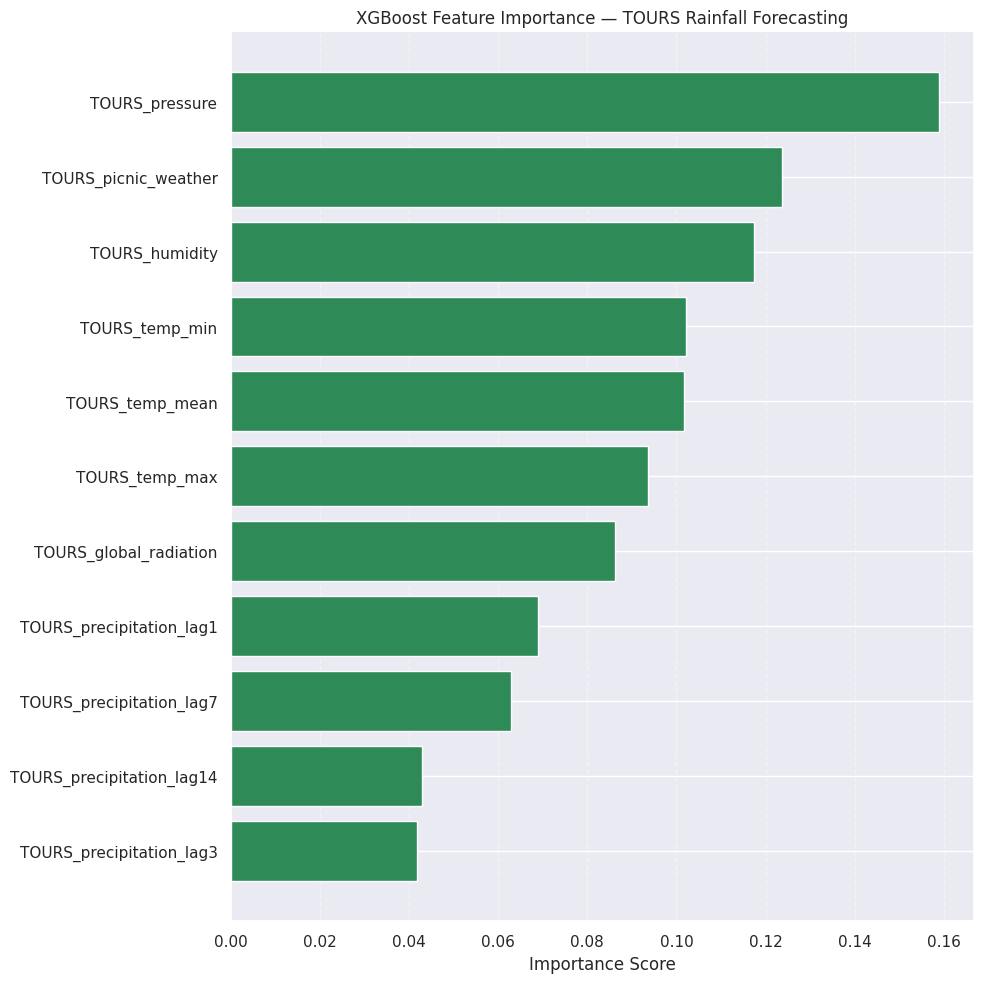

In [ ]:
# ============================================================
# Run XGB Feature Importance for All Stations Automatically
# ============================================================

for station in valid_stations:
    try:
        plot_xgb_feature_importance(station)
    except Exception as e:
        print(f" Skipped {station} due to error: {e}")

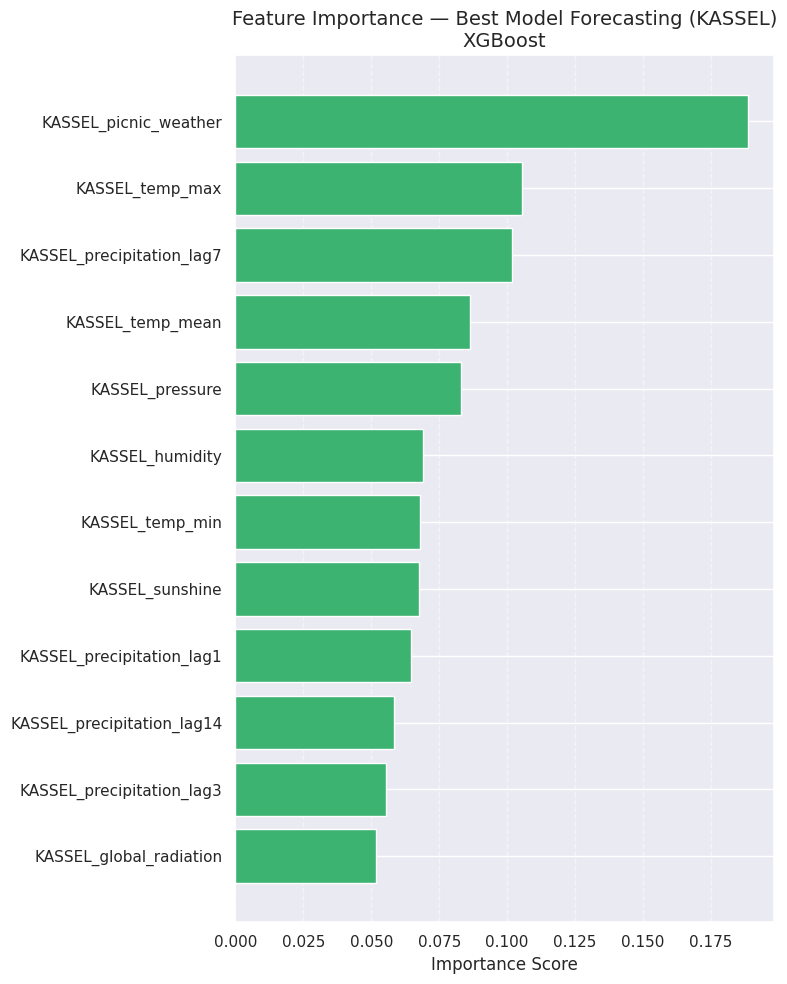

In [ ]:
# ========================================================
# Feature Importance for Best Forecast Model — KASSEL (XGBoost)
# ========================================================
station = "KASSEL"
target = f"{station}_precipitation"

# Select station columns
station_cols = [c for c in df.columns if c.startswith(station + "_")]
data = df[station_cols].dropna().copy()

# Create lag features (same as pipeline)
for lag in [1, 3, 7, 14]:
    data[f"{target}_lag{lag}"] = data[target].shift(lag)
data.dropna(inplace=True)

# Train/Test split (80/20)
total_len = len(data)
train_end = int(total_len * 0.8)
train = data.iloc[:train_end]
test = data.iloc[train_end:]

X_train, y_train = train.drop(columns=[target]), train[target]

# Scale (same as pipeline)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

# Train XGBoost
xgb_best = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6)
xgb_best.fit(X_train_s, y_train)

# Extract feature importance
importance = xgb_best.feature_importances_
features = X_train.columns

# Sort by importance
sorted_idx = np.argsort(importance)
sorted_features = features[sorted_idx]
sorted_importance = importance[sorted_idx]

# Plot
plt.figure(figsize=(8, 10))
plt.barh(sorted_features, sorted_importance, color="mediumseagreen")
plt.title(f"Feature Importance — Best Model Forecasting ({station})\nXGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

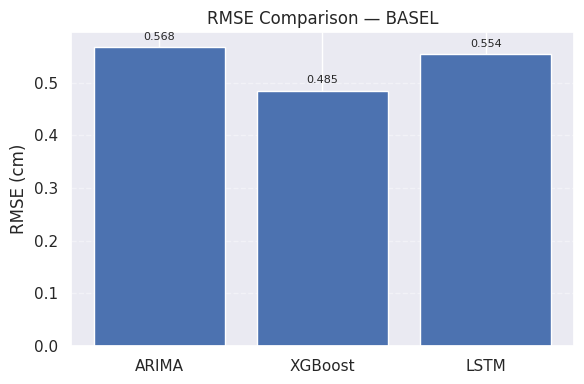

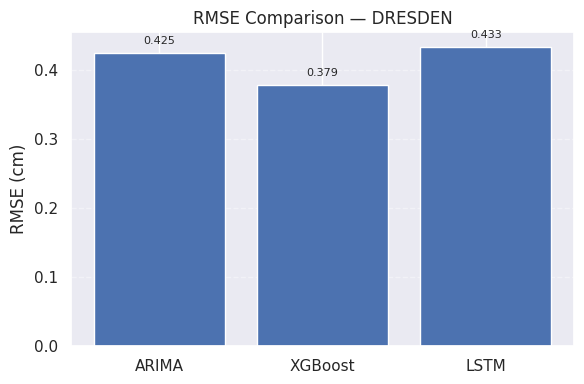

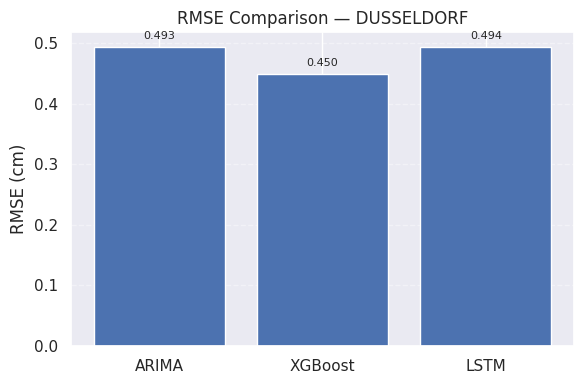

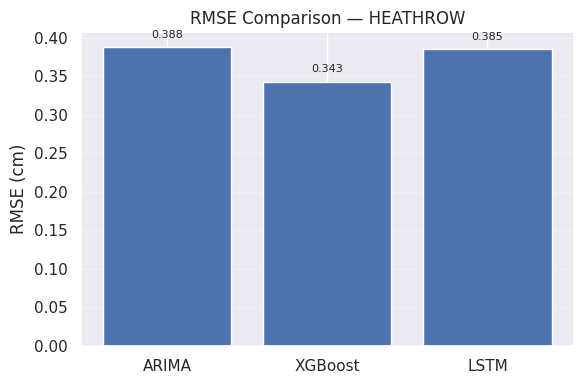

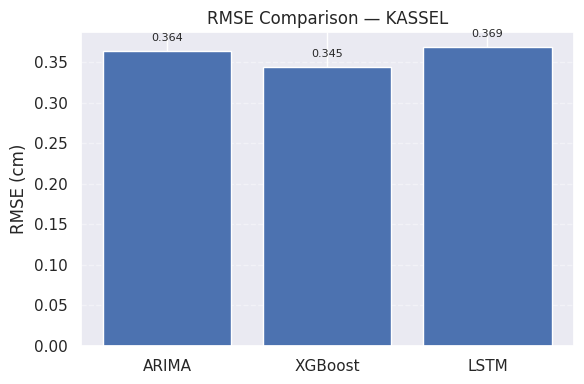

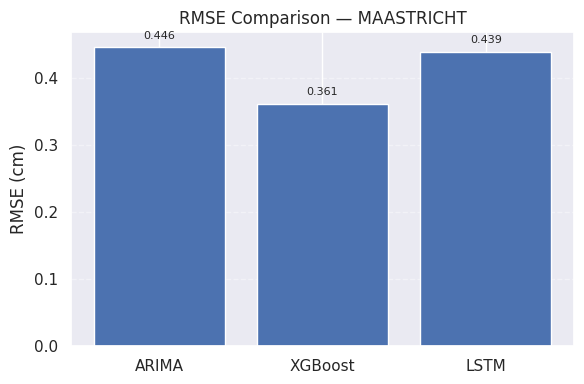

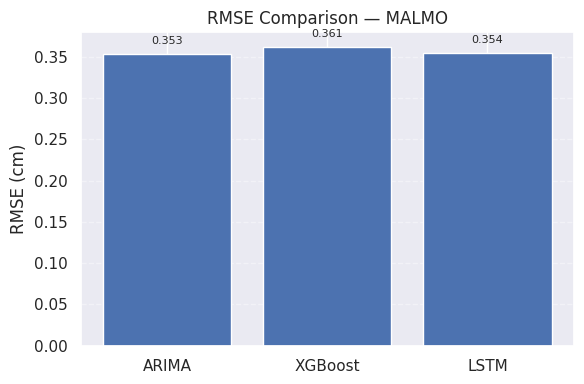

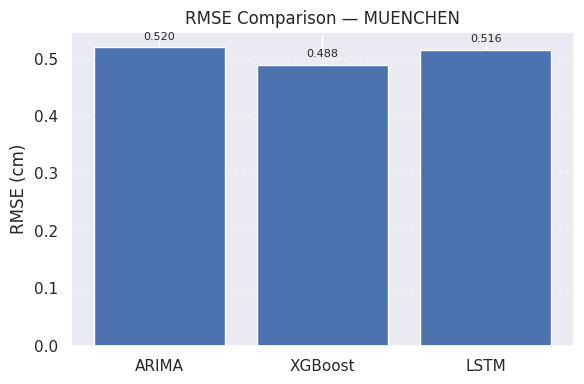

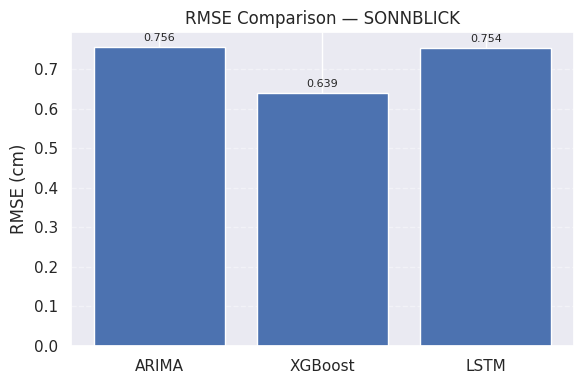

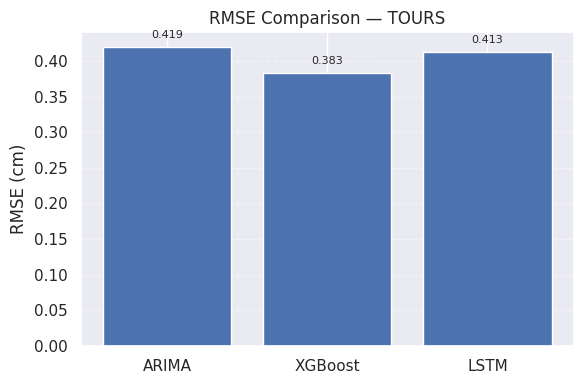

In [ ]:
# =====================================================================
# 2) A – Model Performance Plots per Station (RMSE)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

for idx, row in results_df.iterrows():
    station = row["Station"]
    rmse_vals = [row["ARIMA_RMSE"], row["XGB_RMSE"], row["LSTM_RMSE"]]
    models = ["ARIMA", "XGBoost", "LSTM"]

    plt.figure(figsize=(6,4))
    bars = plt.bar(models, rmse_vals)
    plt.title(f"RMSE Comparison — {station}")
    plt.ylabel("RMSE (cm)")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Annotate values on top
    for bar, val in zip(bars, rmse_vals):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
# =====================================================================
# 3) B – Multi-Station Future Trends (XGBoost Only)
# =====================================================================

def get_xgb_future_forecast(station_name, future_days=30):
    """
    Uses same logic as pipeline but only trains XGBoost
    and returns future forecast series for that station.
    """
    target = f"{station_name}_precipitation"
    station_cols = [c for c in df.columns if c.startswith(station_name + "_")]
    data = df[station_cols].dropna().copy()

    if target not in data.columns:
        print(f" No precipitation for {station_name}, skipping.")
        return None

    # Lag features
    for lag in [1, 3, 7, 14]:
        data[f"{target}_lag{lag}"] = data[target].shift(lag)
    data.dropna(inplace=True)

    # Train/Test split (80/20)
    total_len = len(data)
    train_end = int(total_len * 0.8)
    train = data.iloc[:train_end]
    test = data.iloc[train_end:]

    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    xgb = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6)
    xgb.fit(X_train_s, y_train)

    # Recursive multi-step forecasting
    future_X = X_test_s[-1:].copy()
    future_preds = []

    for _ in range(future_days):
        nxt = xgb.predict(future_X)[0]
        future_preds.append(nxt)
        future_X = np.roll(future_X, 1)
        future_X[0, 0] = nxt

    # Build a date index starting from last known date
    start_date = y_test.index[-1] + pd.Timedelta(days=1)
    future_index = pd.date_range(start=start_date, periods=future_days, freq="D")

    return pd.Series(future_preds, index=future_index, name=station_name)


# ---- Build multi-station future forecast matrix ----
future_days = 30
forecast_dict = {}

for st in results_df["Station"]:
    print(f"Generating XGBoost forecast for {st} ...")
    s = get_xgb_future_forecast(st, future_days=future_days)
    if s is not None:
        forecast_dict[st] = s

future_df = pd.DataFrame(forecast_dict)

print("\n Combined future forecast (XGB) shape:", future_df.shape)
display(future_df.head())

Generating XGBoost forecast for BASEL ...
Generating XGBoost forecast for DRESDEN ...
Generating XGBoost forecast for DUSSELDORF ...
Generating XGBoost forecast for HEATHROW ...
Generating XGBoost forecast for KASSEL ...
Generating XGBoost forecast for MAASTRICHT ...
Generating XGBoost forecast for MALMO ...
Generating XGBoost forecast for MUENCHEN ...
Generating XGBoost forecast for SONNBLICK ...
Generating XGBoost forecast for TOURS ...

 Combined future forecast (XGB) shape: (30, 10)


,BASEL,DRESDEN,DUSSELDORF,HEATHROW,KASSEL,MAASTRICHT,MALMO,MUENCHEN,SONNBLICK,TOURS
2010-01-02,2.890,0.202,0.119,0.174,0.723,0.188,0.015,0.793,0.319,0.443
2010-01-03,0.095,0.104,0.075,0.339,0.109,0.085,0.533,0.504,0.597,0.067
2010-01-04,0.278,0.053,0.445,0.555,0.050,0.029,0.678,0.868,0.355,-0.003
2010-01-05,0.047,-0.018,0.436,0.194,0.059,0.029,0.404,0.174,0.508,0.196
2010-01-06,0.188,0.089,0.346,0.292,0.159,0.226,0.143,0.243,0.188,0.335


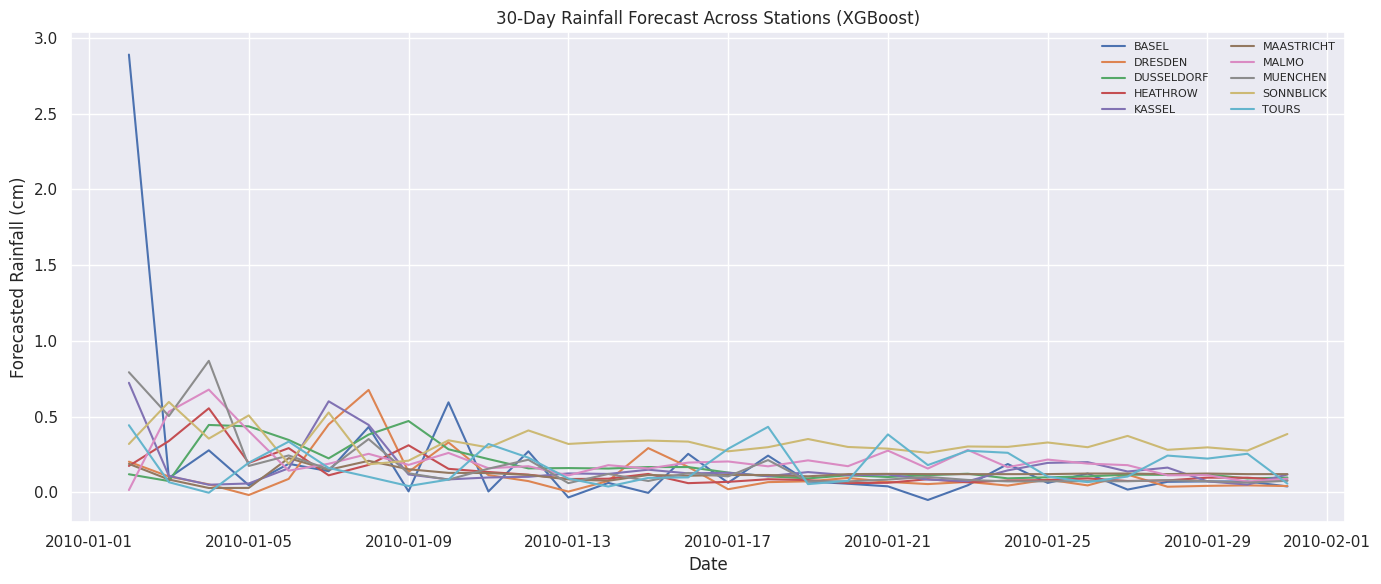

In [ ]:
plt.figure(figsize=(14,6))
for col in future_df.columns:
    plt.plot(future_df.index, future_df[col], label=col)

plt.title(f"30-Day Rainfall Forecast Across Stations (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Forecasted Rainfall (cm)")
plt.grid(True)
plt.legend(fontsize=8, frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# 4) D – Statistical Significance: ARIMA vs XGB vs LSTM (RMSE)
# =====================================================================
from scipy.stats import ttest_rel, wilcoxon

arima_rmse = results_df["ARIMA_RMSE"]
xgb_rmse   = results_df["XGB_RMSE"]
lstm_rmse  = results_df["LSTM_RMSE"]

# Paired t-test: ARIMA vs XGB
t_AX, p_AX = ttest_rel(arima_rmse, xgb_rmse)
t_LX, p_LX = ttest_rel(lstm_rmse, xgb_rmse)

# Non-parametric Wilcoxon test (robust check)
w_AX, wp_AX = wilcoxon(arima_rmse, xgb_rmse)
w_LX, wp_LX = wilcoxon(lstm_rmse, xgb_rmse)

print(" Paired t-test on RMSE")
print(f"ARIMA vs XGBoost: t={t_AX:.3f}, p={p_AX:.5f}")
print(f"LSTM  vs XGBoost: t={t_LX:.3f}, p={p_LX:.5f}")

print("\n Wilcoxon Signed-Rank Test on RMSE")
print(f"ARIMA vs XGBoost: W={w_AX:.3f}, p={wp_AX:.5f}")
print(f"LSTM  vs XGBoost: W={w_LX:.3f}, p={wp_LX:.5f}")

 Paired t-test on RMSE
ARIMA vs XGBoost: t=4.373, p=0.00179
LSTM  vs XGBoost: t=4.464, p=0.00157

 Wilcoxon Signed-Rank Test on RMSE
ARIMA vs XGBoost: W=1.000, p=0.00391
LSTM  vs XGBoost: W=1.000, p=0.00391
